# 01. EDA — Day 1 EDA & 모델 전략 근거 (Classification)

> Day 1 보고서(모델 전략 수립)의 모든 그림·수치는 이 노트북에서 나옴. Day 2 모델링은 `02_feature_engineering.ipynb`, `03_modeling.ipynb` 참고

**이 노트북이 하는 일** : 보고서에 넣을 "그래프 + 숫자 근거"를 만든다.

- 사용 데이터 (가이드 Day 1 = Batch 1 + 2 + 3) : Batch 1 (2017-05-12, **학습용**) / Batch 2 (2018-02-20, **테스트용**) / Batch 3 (2018-04-12, **추가 검증용**, Day 2 선택)
- 문제 정의 : 배터리가 **550 사이클 이상 버티면 Long(1), 못 버티면 Short(0)** 으로 분류
- 모든 분석은 "세 배치가 서로 비슷한가?" 를 함께 본다. 학습(B1)과 시험(B2·B3)이 다르면 모델 성능이 떨어지기 때문

| 섹션 | 질문 (가이드) | 한 줄 요약 |
|---|---|---|
| 0 | 데이터 준비 | 파일 읽기, 쓸 수 없는 셀 빼기, 셀마다 숫자 요약(피처) 만들기 |
| 1 | Cycle Life 분포 | 수명이 어떻게 퍼져 있고, Long/Short 가 몇 개씩인가 |
| 2 | 열화 곡선 | 용량이 어떤 모양으로 줄어드는가, 언제 급격히 꺾이는가 |
| 3 | ΔQ(V) 곡선 | 초기 사이클에서 장/단수명 차이가 보이는가 |
| 4 | 충전 조건 | 빠르게 충전하면 정말 수명이 짧은가 |
| 5 | 상관관계 | 어떤 피처를 쓰고, 어떤 피처를 버릴 것인가 |
| 6 | 핵심 리스크 | B1 으로 배운 규칙이 B2 에서도 통하는가 |
| 7 | 요약 표 | 보고서에 옮길 숫자 모음 |

In [1]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from scipy.signal import medfilt

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR  = '../data/raw' if os.path.exists('../data/raw') else '../archive'   # .mat 파일 위치 (data/README.md)
CACHE     = '../data/interim/cache_eda.pkl'   # 한 번 읽은 결과를 저장해 두는 파일 (다음 실행부터 빠름)
os.makedirs('../data/interim', exist_ok=True)
THRESHOLD = 550                # Long / Short 를 나누는 기준 사이클 (가이드 지정)
EOL_AH    = 0.88               # 수명 종료 기준 용량 = 공칭 1.1Ah 의 80%

BATCH_FILES = {
    'B1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'B2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'B3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
BATCHES     = list(BATCH_FILES)
BATCH_COLOR = {'B1': 'tab:blue', 'B2': 'tab:orange', 'B3': 'tab:green'}
# 원논문 코드에서 노이즈 채널로 제거한 Batch 3 셀 (c23, c32 는 수명 값 자체가 없음)
PAPER_NOISY_B3 = ['B3c2', 'B3c37', 'B3c42', 'B3c43']
LABEL_COLOR = {1: 'tab:blue', 0: 'tab:red'}

## 0. 데이터 준비

### 0-1. 파일 읽기
- `.mat` 파일은 수 GB 라서 통째로 읽으면 느리다. **필요한 값만 골라서** 읽는다 (`h5py` 사용).
- 읽는 값
  - `cycle_life` : 정답(수명)
  - `policy_readable` : 충전 방식 이름 (예: `5.4C(50%)-3C`)
  - `summary` : 사이클마다 1줄씩 요약된 값 (방전용량 QD, 내부저항 IR, 온도, 충전시간)
  - `Qdlin` : 사이클 1~100 의 "전압별 방전 용량 곡선" (ΔQ(V) 계산용, 곡선 1개 = 점 1000개)
- **사이클 번호 = 배열 순서(index)** 로 통일 (논문 코드와 같은 방식). Batch 1 은 0번 사이클이 비어 있어서 1번부터 사용.

In [2]:
def _str(f, ref):
    """MATLAB 문자열(숫자 배열로 저장됨)을 파이썬 문자열로 변환"""
    return ''.join(chr(c) for c in f[ref][()].flatten())

def load_batch(path, batch_name, max_cycle=100):
    """배치 파일 하나에서 셀별로 필요한 값만 꺼내 list 로 반환"""
    cells = []
    with h5py.File(path, 'r') as f:
        b = f['batch']
        for i in range(b['summary'].shape[0]):
            s = f[b['summary'][i, 0]]
            summary = {k: s[k][0, :].astype(float) for k in s.keys()}
            cyc = f[b['cycles'][i, 0]]
            n_rows = cyc['Qdlin'].shape[0]
            qdlin = np.full((max_cycle + 1, 1000), np.nan)   # 행 = 사이클 번호, 열 = 전압 1000개 지점
            for j in range(1, min(max_cycle, n_rows - 1) + 1):
                q = f[cyc['Qdlin'][j, 0]][()]
                if q.size == 1000:
                    qdlin[j] = q.ravel()
            cells.append({
                'batch'      : batch_name,
                'cell'       : f'{batch_name}c{i}',
                'cycle_life' : float(f[b['cycle_life'][i, 0]][()].item()),
                'policy'     : _str(f, b['policy_readable'][i, 0]),
                'summary'    : summary,
                'Qdlin'      : qdlin,
                'Vdlin'      : f[b['Vdlin'][i, 0]][()].ravel(),
            })
    return cells

raw = None
if os.path.exists(CACHE):
    with open(CACHE, 'rb') as fp:
        raw = pickle.load(fp)
    if {c['batch'] for c in raw} != set(BATCHES):       # 배치 구성이 바뀌면 다시 읽음
        raw = None
    else:
        print(f'캐시 로드 : {CACHE}')
if raw is None:
    raw = []
    for name, fn in BATCH_FILES.items():
        print(f'{name} 로딩 중 ... ({fn})')
        raw += load_batch(os.path.join(DATA_DIR, fn), name)
    with open(CACHE, 'wb') as fp:
        pickle.dump(raw, fp)
    print(f'캐시 저장 : {CACHE}')

print(f'전체 셀 수 : {len(raw)}  ' +
      str(pd.Series([c["batch"] for c in raw]).value_counts().to_dict()))

B1 로딩 중 ... (2017-05-12_batchdata_updated_struct_errorcorrect.mat)


B2 로딩 중 ... (2018-02-20_batchdata_updated_struct_errorcorrect.mat)


B3 로딩 중 ... (2018-04-12_batchdata_updated_struct_errorcorrect.mat)


캐시 저장 : ../data/interim/cache_eda.pkl
전체 셀 수 : 139  {'B2': 47, 'B1': 46, 'B3': 46}


### 0-2. 쓸 수 없는 셀 걸러내기

1. **수명 값이 없는 셀 → 제외**
   B2 의 `VarCharge-*`(충전 속도를 계속 바꾼 실험), `*(SLOWCYCLE`(느린 진단 실험) 셀은 다른 목적의 실험이라 수명 정답이 없음
   B3 는 원논문 코드에서 노이즈 채널로 제거한 4셀(c2, c37, c42, c43)도 함께 제외 → 원논문 2차 테스트셋과 같은 40셀
2. **중도 종료(censored) 셀 → 표시만 해 둠**
   용량이 0.88Ah 까지 떨어지기 **전에** 실험이 끝난 셀. 기록된 수명보다 실제 수명이 더 길다는 뜻.
   이 셀들은 어차피 550 보다 길어서 **Long 라벨은 맞음** → 분류에서는 그대로 사용 가능
3. **전압 기준선(Vdlin) 확인**
   모든 셀이 같은 전압 지점에서 측정돼 있어야 ΔQ(V) 곡선을 셀끼리 비교할 수 있음

In [3]:
rows = []
for c in raw:
    qd = c['summary']['QDischarge']
    rows.append({
        'cell'       : c['cell'],
        'batch'      : c['batch'],
        'policy'     : c['policy'],
        'cycle_life' : c['cycle_life'],
        'n_cycles'   : len(qd),
        'last_QD'    : medfilt(qd, 5)[-3],     # 마지막 용량 (노이즈 제거 후)
    })
meta = pd.DataFrame(rows)

meta['paper_noisy'] = meta['cell'].isin(PAPER_NOISY_B3)
meta['excluded']  = meta['cycle_life'].isna() | meta['paper_noisy']
meta['censored']  = (~meta['excluded']) & (meta['last_QD'] > EOL_AH + 0.01)
meta['newstruct'] = meta['policy'].str.contains('newstructure')

print('[제외 셀 : 수명 값 없음 또는 원논문 노이즈 채널]')
print(meta.loc[meta['excluded'], ['cell', 'policy', 'cycle_life', 'paper_noisy']].to_string(index=False))
print('\n[중도 종료 셀 : 0.88Ah 도달 전 실험 종료]')
print(meta.loc[meta['censored'], ['cell', 'policy', 'cycle_life', 'last_QD']].round(3).to_string(index=False))

vd = np.vstack([c['Vdlin'] for c in raw])
print(f'\nVdlin 셀 간 최대 차이 : {np.abs(vd - vd[0]).max():.2e}  (0 이면 모든 셀이 같은 전압 지점)')
print(f'Vdlin 범위 : {vd[0].min():.2f} ~ {vd[0].max():.2f} V')

# 가이드 : "충전 커브 시작 시점이 배치별로 상이 → Qdlin 단순 비교 시 왜곡" 확인
# 방전 시작점(3.5V)의 Qdlin 값이 배치마다 0 으로 맞춰져 있는지, 사이클 10 곡선의 끝값(총 방전 용량)이 다른지 확인
chk = pd.DataFrame([{'batch': c['batch'], 'Q10_at_3.5V': c['Qdlin'][10][0], 'Q10_at_2.0V': c['Qdlin'][10][-1]} for c in raw])
display(chk.groupby('batch').agg(['mean', 'std']).round(4))
print('→ ΔQ = 같은 셀의 (사이클 100 − 사이클 10) 이므로, 셀·배치별 시작점 차이(상수)는 빼기에서 상쇄됨')

[제외 셀 : 수명 값 없음 또는 원논문 노이즈 채널]
 cell                      policy  cycle_life  paper_noisy
B2c22      VarCharge-2C-100cycles         NaN        False
B2c23      VarCharge-4C-100cycles         NaN        False
B2c35      VarCharge-6C-100cycles         NaN        False
B2c36      VarCharge-8C-100cycles         NaN        False
B2c37    3.6C(80%)-3.6C(SLOWCYCLE         NaN        False
B2c38    4.8C(80%)-4.8C(SLOWCYCLE         NaN        False
B2c39       3.6C(9%)-5C(SLOWCYCLE         NaN        False
B2c40      5.2C(58%)-4C(SLOWCYCLE         NaN        False
 B3c2 5.6C(19%)-4.6C-newstructure      1267.0         True
B3c23 4.8C(80%)-4.8C-newstructure         NaN        False
B3c32 4.8C(80%)-4.8C-newstructure         NaN        False
B3c37 4.8C(80%)-4.8C-newstructure      1390.0         True
B3c42 4.8C(80%)-4.8C-newstructure      1642.0         True
B3c43     5C(67%)-4C-newstructure      1046.0         True

[중도 종료 셀 : 0.88Ah 도달 전 실험 종료]
 cell         policy  cycle_life  last_QD
 B1c0 3.6C(

Q10_at_3.5V         Q10_at_2.0V        
             mean     std        mean     std
batch                                        
B1        -0.0003  0.0001      1.0662  0.0084
B2        -0.0002  0.0001      1.0572  0.0091
B3        -0.0002  0.0001      1.0509  0.0073

→ ΔQ = 같은 셀의 (사이클 100 − 사이클 10) 이므로, 셀·배치별 시작점 차이(상수)는 빼기에서 상쇄됨


In [4]:
cells = [c for c, ex in zip(raw, meta['excluded']) if not ex]
meta  = meta[~meta['excluded']].reset_index(drop=True)
meta['cycle_life'] = meta['cycle_life'].astype(int)
meta['label']      = (meta['cycle_life'] >= THRESHOLD).astype(int)
V = cells[0]['Vdlin']

print(f'분석 대상 셀 : {len(cells)}  ' + str(meta['batch'].value_counts().to_dict()))

분석 대상 셀 : 125  {'B1': 46, 'B3': 40, 'B2': 39}


### 0-3. 셀마다 "숫자 요약(피처)" 만들기

모델은 곡선을 그대로 받지 못하므로, 셀 하나를 숫자 몇 개로 요약한다.
같은 피처를 **두 가지 관측 기간** 으로 만들어서 어느 쪽이 더 쓸모 있는지 비교한다.

| 접두어 | 관측 기간 | 의미 |
|---|---|---|
| `w5_` | 사이클 1~5 | 논문 분류 모델 방식 : 공장 출하 직후 5번만 돌려보고 판정 |
| `w100_` | 사이클 1~100 | 논문 회귀 모델 방식 : 100번 돌려보고 판정 |

**피처 설명**

| 피처 | 쉬운 설명 |
|---|---|
| `dQ_logvar` | ΔQ(V) 곡선이 얼마나 출렁이는지 (분산) 의 log. **논문에서 가장 강력한 피처** |
| `dQ_logmin` | ΔQ(V) 곡선의 가장 깊은 값 (최솟값 절댓값) 의 log |
| `dQ_mean / skew / kurt` | ΔQ(V) 곡선의 평균 / 비대칭도 / 뾰족함 |
| `QD2` | 사이클 2 의 방전 용량 (초기 용량) |
| `QDmax_m_QD2` | 기간 중 최대 용량 − 사이클 2 용량 (초반에 용량이 얼마나 올라갔는지) |
| `fade_slope` | 기간 중 용량이 사이클당 얼마나 줄었는지 (기울기) |
| `chargetime` | 충전에 걸린 시간 (분) |
| `Tavg / Tmax` | 평균 / 최고 온도 |
| `IR2 / IR_min / IR_delta` | 내부 저항 : 사이클 2 값 / 최솟값 / 기간 중 변화량 |
| `C1, Q1, C2` | 충전 방식 `C1(Q1%)-C2` 를 숫자로 분해 (1단계 속도, 전환 시점 %, 2단계 속도) |
| `Cavg` | 0→80% 충전까지의 **평균 충전 속도**. 충전 방식이 얼마나 공격적인지 하나의 숫자로 표현 |

> **ΔQ(V) 란?** 사이클 100 의 방전 곡선 − 사이클 10 의 방전 곡선. 같은 전압에서 용량이 얼마나 달라졌는지를 보여줌.
> 전체 용량은 거의 그대로여도 곡선 **모양** 이 미세하게 바뀌는데, 이 변화가 나중의 수명을 알려주는 신호가 된다.

In [5]:
POLICY_RE = re.compile(r'([\d.]+)C\((\d+)%\)-([\d.]+)C')

def parse_policy(p):
    """'5.4C(50%)-3C' → C1=5.4, Q1=50, C2=3, Cavg=0→80% 평균 C-rate"""
    m = POLICY_RE.search(p)
    if not m:
        return np.nan, np.nan, np.nan, np.nan
    c1, q1, c2 = float(m.group(1)), float(m.group(2)) / 100, float(m.group(3))
    q1 = min(q1, 0.8)
    t = q1 / c1 + (0.8 - q1) / c2          # 0→80% 충전에 걸리는 시간 (시간 단위)
    return c1, q1 * 100, c2, 0.8 / t

def dq_stats(dq, prefix):
    """ΔQ(V) 곡선 하나 → 통계값 5개"""
    dq = dq[~np.isnan(dq)]
    if dq.size == 0:
        return {f'{prefix}_{k}': np.nan for k in ['logvar', 'logmin', 'mean', 'skew', 'kurt']}
    return {
        f'{prefix}_logvar' : np.log10(np.var(dq)),
        f'{prefix}_logmin' : np.log10(np.abs(dq.min())),
        f'{prefix}_mean'   : dq.mean(),
        f'{prefix}_skew'   : stats.skew(dq),
        f'{prefix}_kurt'   : stats.kurtosis(dq),
    }

def window_feats(s, last, prefix):
    """summary 값으로 만드는 피처 (사이클 1 ~ last)"""
    idx = np.arange(1, last + 1)
    qd  = s['QDischarge'][idx]
    x   = idx[1:]                                  # 사이클 2 ~ last
    slope, _ = np.polyfit(x, s['QDischarge'][x], 1)
    ir = s['IR'][idx]
    ir_valid = ir[ir > 0]
    return {
        f'{prefix}_fade_slope' : slope,
        f'{prefix}_chargetime' : np.median(s['chargetime'][idx]),
        f'{prefix}_Tavg'       : s['Tavg'][idx].mean(),
        f'{prefix}_Tmax'       : s['Tmax'][idx].max(),
        f'{prefix}_IR_min'     : ir_valid.min() if ir_valid.size else np.nan,
        f'{prefix}_IR_delta'   : s['IR'][last] - s['IR'][2],
        f'{prefix}_QDmax_m_QD2': qd.max() - s['QDischarge'][2],
    }

feat_rows = []
for c, m in zip(cells, meta.itertuples()):
    s = c['summary']
    Q = c['Qdlin']
    c1, q1, c2, cavg = parse_policy(c['policy'])
    r = {'cell': m.cell, 'QD2': s['QDischarge'][2], 'IR2': s['IR'][2],
         'C1': c1, 'Q1': q1, 'C2': c2, 'Cavg': cavg}
    r.update(dq_stats(Q[5]   - Q[4],  'w5_dQ'))      # 5사이클 기간 : ΔQ_5-4
    r.update(dq_stats(Q[100] - Q[10], 'w100_dQ'))    # 100사이클 기간 : ΔQ_100-10
    r.update(window_feats(s, 5,   'w5'))
    r.update(window_feats(s, 100, 'w100'))
    feat_rows.append(r)

feat = meta.merge(pd.DataFrame(feat_rows), on='cell')
feat['log_life'] = np.log10(feat['cycle_life'])
print(feat.shape)
feat.head()

(125, 42)


,cell,batch,policy,cycle_life,n_cycles,last_QD,paper_noisy,excluded,censored,newstruct,...,w5_IR_delta,w5_QDmax_m_QD2,w100_fade_slope,w100_chargetime,w100_Tavg,w100_Tmax,w100_IR_min,w100_IR_delta,w100_QDmax_m_QD2,log_life
0,B1c0,B1,3.6C(80%)-3.6C,1190,1189,1.026499,False,False,True,False,...,-0.000101,0.001676,-0.000216,13.358123,31.603301,35.994705,0.016444,-0.000074,0.467154,3.075547
1,B1c1,B1,3.6C(80%)-3.6C,1179,1178,1.038700,False,False,True,False,...,-0.000151,0.001932,0.000001,13.341605,31.329102,34.712265,0.016764,-0.000005,0.007977,3.071514
2,B1c2,B1,3.6C(80%)-3.6C,1177,1176,1.043586,False,False,True,False,...,-0.000168,0.001715,0.000007,13.341564,31.478410,35.127342,0.016613,0.000027,0.006738,3.070776
3,B1c3,B1,4C(80%)-4C,1226,1225,0.971356,False,False,True,False,...,-0.000024,0.001884,0.000014,12.092219,29.940748,31.691414,0.016098,0.000098,0.005025,3.088490
4,B1c4,B1,4C(80%)-4C,1227,1226,1.021865,False,False,True,False,...,-0.000057,0.001740,0.000016,12.092206,31.448376,35.651741,0.016369,0.000011,0.005304,3.088845


In [6]:
def auc(x, y):
    """
    피처 하나로 Long/Short 를 얼마나 잘 나누는지 (AUC 기반 '분리력')
    - 0.5 : 동전 던지기 수준 (전혀 못 나눔)
    - 1.0 : 어떤 기준값 하나로 Long/Short 를 완벽하게 나눌 수 있음
    - 방향(값이 클수록 Long 인지 작을수록 Long 인지)은 Spearman 부호로 확인
    """
    ok = ~np.isnan(x)
    x, y = x[ok], y[ok]
    if y.min() == y.max():
        return np.nan
    u = stats.mannwhitneyu(x[y == 1], x[y == 0]).statistic
    a = u / ((y == 1).sum() * (y == 0).sum())
    return max(a, 1 - a)

---
## Q1. Cycle Life 분포는 어떻게 생겼는가?

**그래프 읽는 법**
- 왼쪽 : 배치별 수명 히스토그램. 검은 점선(550) 왼쪽 = Short, 오른쪽 = Long
- 가운데 : 같은 그래프를 log 스케일로. 수명은 보통 log 로 보면 더 고르게 퍼짐
- 오른쪽 : 배치별 Long / Short 개수. **학습용 B1 에 Short 가 몇 개 있는지** 가 가장 중요

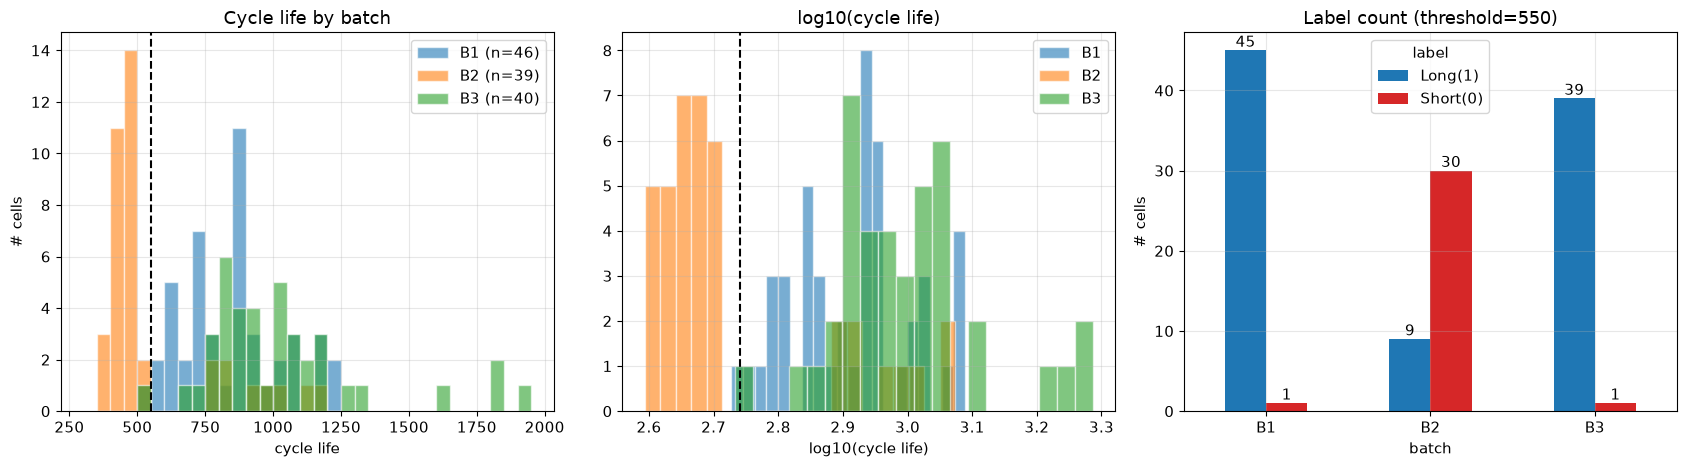

,count,mean,std,min,25%,50%,75%,max,skew,short(<500),long(>1000),label=1 비율
batch,,,,,,,,,,,,
B1,46.0,845.0,185.0,534.0,703.0,858.0,914.0,1227.0,0.45,0.00,0.22,0.98
B2,39.0,566.0,222.0,392.0,440.0,472.0,508.0,1186.0,1.64,0.72,0.08,0.23
B3,40.0,1032.0,309.0,541.0,827.0,964.0,1123.0,1935.0,1.52,0.00,0.48,0.98


KS 검정 (B1 vs B2 수명 분포가 같은가?) : stat=0.769, p=6.63e-13
KS 검정 (B1 vs B3 수명 분포가 같은가?) : stat=0.361, p=5.28e-03
  → p < 0.05 이면 "두 배치의 수명 분포는 통계적으로 다르다"


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
bins = np.arange(300, 2000, 50)
for b in BATCHES:
    sub = feat[feat['batch'] == b]
    axes[0].hist(sub['cycle_life'], bins=bins, alpha=0.6, label=f'{b} (n={len(sub)})',
                 color=BATCH_COLOR[b], edgecolor='white')
    axes[1].hist(sub['log_life'], bins=20, alpha=0.6, label=b, color=BATCH_COLOR[b], edgecolor='white')
axes[0].axvline(THRESHOLD, color='k', ls='--')
axes[0].set(title='Cycle life by batch', xlabel='cycle life', ylabel='# cells')
axes[1].axvline(np.log10(THRESHOLD), color='k', ls='--')
axes[1].set(title='log10(cycle life)', xlabel='log10(cycle life)')
for ax in axes[:2]:
    ax.legend()

ct = pd.crosstab(feat['batch'], feat['label'].map({1: 'Long(1)', 0: 'Short(0)'}))
ct.plot.bar(ax=axes[2], color=['tab:blue', 'tab:red'], rot=0)
for p in axes[2].patches:
    axes[2].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')
axes[2].set(title=f'Label count (threshold={THRESHOLD})', ylabel='# cells')
plt.tight_layout(); plt.show()

summary_q1 = feat.groupby('batch')['cycle_life'].describe().round(0)
summary_q1['skew']        = feat.groupby('batch')['cycle_life'].skew().round(2)
summary_q1['short(<500)'] = feat.groupby('batch')['cycle_life'].apply(lambda x: (x < 500).mean()).round(2)
summary_q1['long(>1000)'] = feat.groupby('batch')['cycle_life'].apply(lambda x: (x > 1000).mean()).round(2)
summary_q1['label=1 비율'] = feat.groupby('batch')['label'].mean().round(2)
display(summary_q1)

ks = stats.ks_2samp(feat.loc[feat.batch == 'B1', 'cycle_life'], feat.loc[feat.batch == 'B2', 'cycle_life'])
ks13 = stats.ks_2samp(feat.loc[feat.batch == 'B1', 'cycle_life'], feat.loc[feat.batch == 'B3', 'cycle_life'])
print(f'KS 검정 (B1 vs B2 수명 분포가 같은가?) : stat={ks.statistic:.3f}, p={ks.pvalue:.2e}')
print(f'KS 검정 (B1 vs B3 수명 분포가 같은가?) : stat={ks13.statistic:.3f}, p={ks13.pvalue:.2e}')
print('  → p < 0.05 이면 "두 배치의 수명 분포는 통계적으로 다르다"')

**이상치 셀 찾기**
- `z_in_policy` : 같은 충전 방식을 쓴 셀들끼리 비교했을 때 얼마나 튀는지. |z| ≥ 1.5 면 확인 대상
- `newstruct` : B2 에서 충전 방식 이름 뒤에 `-newstructure` 가 붙은 셀. 다른 그룹처럼 행동하는지 확인

In [8]:
feat['policy_base'] = feat['policy'].str.replace('-newstructure', '', regex=False)
g = feat.groupby(['batch', 'policy_base'])['cycle_life']
feat['policy_mean'] = g.transform('mean')
feat['z_in_policy'] = (feat['cycle_life'] - feat['policy_mean']) / g.transform('std')

cols = ['cell', 'batch', 'policy', 'cycle_life', 'policy_mean', 'z_in_policy', 'censored', 'newstruct']
print('[같은 충전 방식 안에서 수명이 크게 튀는 셀]')
display(feat.loc[feat['z_in_policy'].abs() >= 1.5, cols].round(1).sort_values('z_in_policy'))

print('[Batch 2 : newstructure 여부별 수명]')
display(feat[feat.batch == 'B2'].groupby('newstruct')['cycle_life'].describe().round(0))

[같은 충전 방식 안에서 수명이 크게 튀는 셀]


,cell,batch,policy,cycle_life,policy_mean,z_in_policy,censored,newstruct
77,B2c33,B2,5.2C(58%)-4C-newstructure,1140,685.1,1.7,False,True
103,B3c19,B3,5.6C(36%)-4.3C-newstructure,1155,930.9,1.7,False,True
78,B2c34,B2,5.6C(26%)-4.5C-newstructure,1186,629.4,1.9,False,True
81,B2c43,B2,4.8C(80%)-4.8C-newstructure,1029,629.1,1.9,False,True
101,B3c17,B3,5.3C(54%)-4C-newstructure,1315,1074.4,1.9,False,True
119,B3c38,B3,5C(67%)-4C-newstructure,1935,1115.7,1.9,False,True


[Batch 2 : newstructure 여부별 수명]


,count,mean,std,min,25%,50%,75%,max
newstruct,,,,,,,,
False,30.0,453.0,35.0,392.0,425.0,451.0,476.0,514.0
True,9.0,942.0,154.0,777.0,809.0,904.0,1029.0,1186.0


### 📌 Q1 결과 해석

**관찰**
- 수명 중앙값 : B2 472 < B1 858 < B3 964. B1 과의 분포 차이는 B2(KS p = 6.6e-13), B3(p = 0.005) 모두 유의함
- Long / Short : **B1 45 / 1, B2 9 / 30, B3 39 / 1** → 학습(B1)과 B3 에는 단수명이 1개뿐, B2 는 대부분 단수명
- 왜도 : B1 0.45(대칭), B2 1.64, B3 1.52(오른쪽 꼬리). B3 는 1935 사이클까지 장수명 셀이 넓게 퍼짐
- B1 의 유일한 Short(534)는 가장 공격적인 충전(5.4C-5.4C) 셀. B2 의 Long 9개는 모두 newstructure 셀(중앙값 904 vs 일반 451), B3 는 40셀 전부 newstructure

**해석**
- 세 배치는 수명 분포와 수명을 가르는 요인(B1 = 충전 방식, B2·B3 = 셀 구조)이 다름. newstructure 셀은 배치와 관계없이 수명이 김

**모델링 시사점**
1. 단수명 예시가 B1 에 1개뿐 → 분류기는 경계를 배울 수 없음 → **수명 숫자 자체를 학습 (회귀 후 550 판정)**
2. "전부 Long" 만 찍어도 B1·B3 98%, B2 23% → **정확도 착시, F1 병행**
3. 오른쪽 꼬리 분포 → **log 변환**
4. 중도 종료 10셀은 모두 Long → 라벨은 유효, 회귀 학습에서는 제외

---
## Q2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?

**용어**
- **열화 곡선** : 사이클(x) 에 따른 방전 용량 QD(y). 측정 튀는 값을 없애려고 5개씩 중앙값으로 부드럽게 함
- **Knee point (무릎점)** : 천천히 줄던 용량이 **갑자기 빨리 줄기 시작하는 지점**.
  곡선을 직선 2개로 근사했을 때 가장 잘 맞는 꺾임 위치로 찾음
- `knee_ratio` = knee / 수명 : 수명의 몇 % 시점에 꺾이는지
- `early_rate` : 사이클 10~100 구간의 용량 감소 속도

※ 중도 종료 셀은 아직 꺾이기 전에 실험이 끝나서 knee 를 찾을 수 없으므로 **knee 분석에서는 제외**

In [9]:
def smooth_qd(s):
    """방전 용량 곡선에서 튀는 값 제거 + 중앙값 필터로 부드럽게"""
    qd = s['QDischarge'][1:].copy()
    qd[(qd < 0.5) | (qd > 1.3)] = np.nan
    qd = pd.Series(qd).interpolate(limit_direction='both').values
    return medfilt(qd, 5)

def find_knee(y):
    """곡선을 직선 2개로 나눠 맞췄을 때 오차가 가장 작은 꺾임 위치"""
    x = np.arange(len(y))
    best, best_k = np.inf, None
    for k in range(int(len(y) * 0.2), int(len(y) * 0.95), 5):
        sse = 0
        for xs, ys in ((x[:k], y[:k]), (x[k:], y[k:])):
            p = np.polyfit(xs, ys, 1)
            sse += ((np.polyval(p, xs) - ys) ** 2).sum()
        if sse < best:
            best, best_k = sse, k
    return best_k

knee_rows = []
for c, m in zip(cells, meta.itertuples()):
    y = smooth_qd(c['summary'])
    k = find_knee(y)
    early = np.polyfit(np.arange(10, 100), y[10:100], 1)[0]
    late  = np.polyfit(np.arange(k, len(y)), y[k:], 1)[0]
    knee_rows.append({'cell': m.cell, 'knee': k + 1, 'early_rate': early, 'late_rate': late})
feat = feat.drop(columns=[c for c in ['knee', 'early_rate', 'late_rate'] if c in feat]) \
           .merge(pd.DataFrame(knee_rows), on='cell')
feat.loc[feat['censored'], ['knee', 'late_rate']] = np.nan       # 중도 종료 셀은 knee 없음
feat['knee_ratio'] = feat['knee'] / feat['cycle_life']

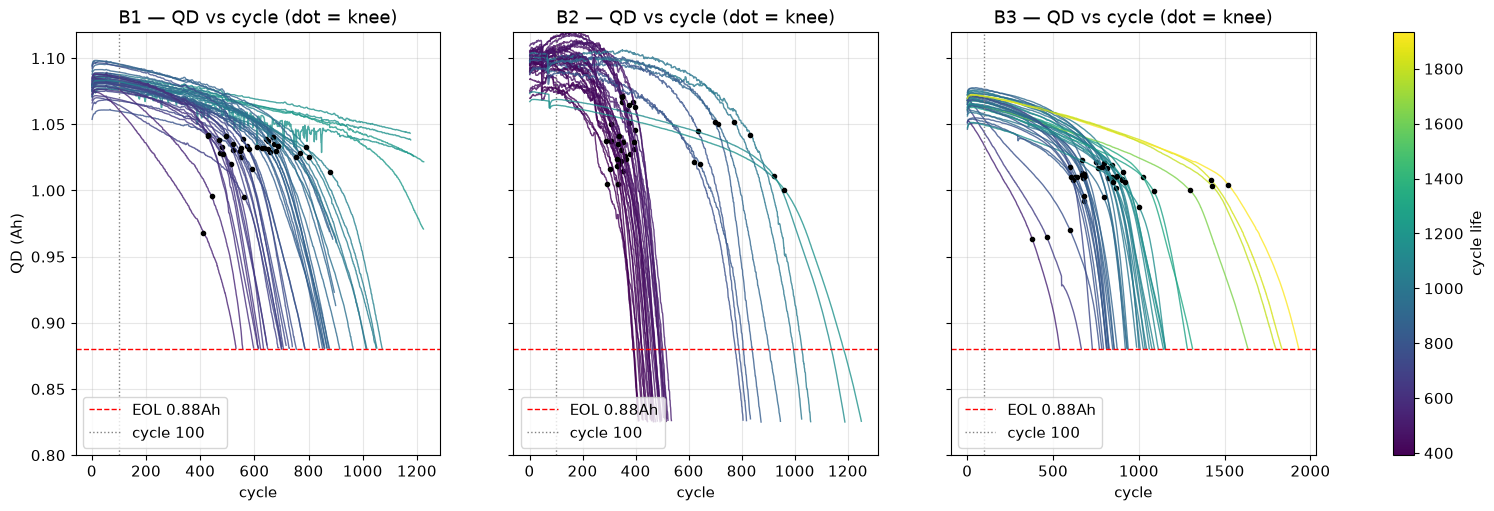

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=True)
norm = plt.Normalize(feat['cycle_life'].min(), feat['cycle_life'].max())
for ax, b in zip(axes, BATCHES):
    for c, m in zip(cells, feat.itertuples()):
        if m.batch != b:
            continue
        y = smooth_qd(c['summary'])
        ax.plot(np.arange(1, len(y) + 1), y, color=cm.viridis(norm(m.cycle_life)), lw=1, alpha=0.8)
        if not np.isnan(m.knee):
            ax.plot(m.knee, y[int(m.knee) - 1], 'o', color='k', ms=3)
    ax.axhline(EOL_AH, color='r', ls='--', lw=1, label='EOL 0.88Ah')
    ax.axvline(100, color='gray', ls=':', lw=1, label='cycle 100')
    ax.set(title=f'{b} — QD vs cycle (dot = knee)', xlabel='cycle', ylim=(0.8, 1.12))
    ax.legend(loc='lower left')
axes[0].set_ylabel('QD (Ah)')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axes, label='cycle life')
plt.show()

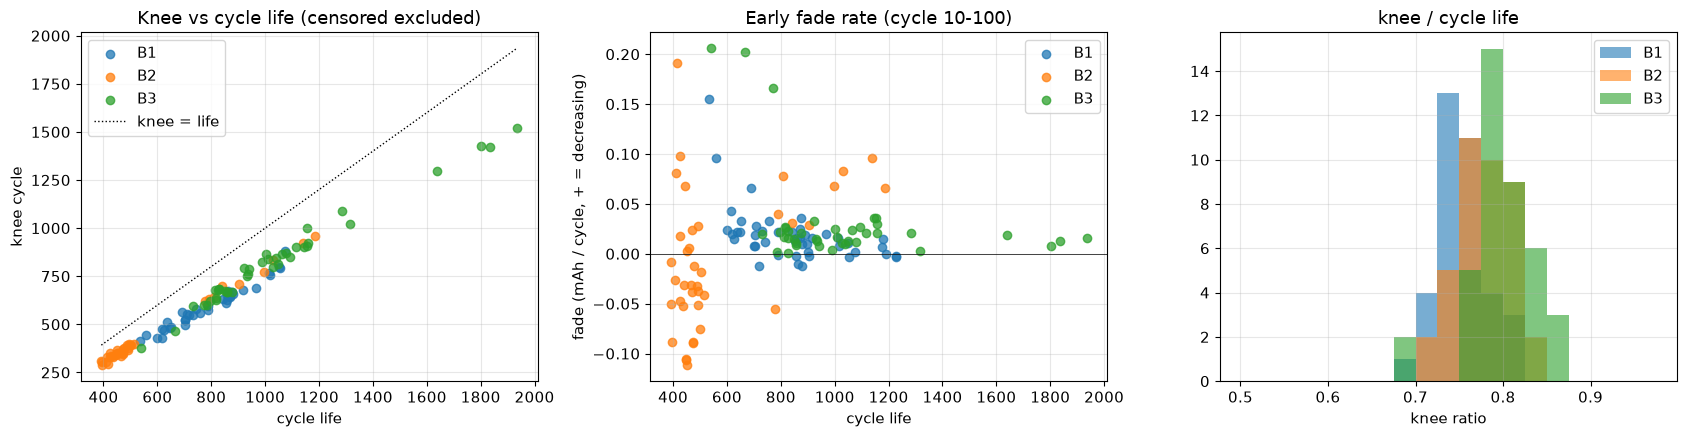

knee  knee_ratio  early_rate  late_rate
batch label                                          
B1    0      412.0     0.77154    -0.00016   -0.00071
      1      579.0     0.74692    -0.00002   -0.00080
B2    0      349.0     0.77099     0.00003   -0.00168
      1      710.0     0.80152    -0.00007   -0.00094
B3    0      378.0     0.69871    -0.00021   -0.00049
      1      796.0     0.79412    -0.00002   -0.00070

Spearman(early_rate, cycle_life) = -0.186 (p=3.7e-02)
Spearman(knee, cycle_life)       = 0.987
knee_ratio 중앙값 = 0.78


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for b in BATCHES:
    sub = feat[feat.batch == b]
    axes[0].scatter(sub['cycle_life'], sub['knee'], label=b, color=BATCH_COLOR[b], alpha=0.75)
    axes[1].scatter(sub['cycle_life'], -sub['early_rate'] * 1e3, label=b, color=BATCH_COLOR[b], alpha=0.75)
    axes[2].hist(sub['knee_ratio'].dropna(), bins=np.arange(0.5, 1.0, 0.025), alpha=0.6, label=b, color=BATCH_COLOR[b])
lim = [feat['cycle_life'].min(), feat['cycle_life'].max()]
axes[0].plot(lim, lim, 'k:', lw=1, label='knee = life')
axes[0].set(title='Knee vs cycle life (censored excluded)', xlabel='cycle life', ylabel='knee cycle')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set(title='Early fade rate (cycle 10-100)', xlabel='cycle life', ylabel='fade (mAh / cycle, + = decreasing)')
axes[2].set(title='knee / cycle life', xlabel='knee ratio')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

display(feat.groupby(['batch', 'label'])[['knee', 'knee_ratio', 'early_rate', 'late_rate']].median().round(5))
r = stats.spearmanr(feat['early_rate'], feat['cycle_life'])
print(f'Spearman(early_rate, cycle_life) = {r.correlation:.3f} (p={r.pvalue:.1e})')
r = stats.spearmanr(feat['knee'], feat['cycle_life'], nan_policy='omit')
print(f'Spearman(knee, cycle_life)       = {r.correlation:.3f}')
print(f"knee_ratio 중앙값 = {feat['knee_ratio'].median():.2f}")

### 📌 Q2 결과 해석

**관찰**
- 사이클 100 이전에는 수명과 관계없이 배치마다 곡선이 좁은 범위에서 겹침
- 세 배치 모두 "완만한 감소 → knee 에서 꺾임 → 추락". knee 는 수명의 약 78% 지점, knee 와 수명의 상관 0.99 (세 배치가 같은 직선 위)
- B2 단수명 셀은 300~400 사이클에 한꺼번에 꺾이고, B3 장수명 셀은 1500 사이클 이후까지 완만함
- 사이클 10~100 의 용량 감소 속도는 수명과 상관이 약함 (Spearman ≈ −0.19)

**해석**
- 열화는 후반에 급격히 빨라지는 비선형 과정이며, 세 배치는 **열화 모양은 같고 속도만 다름**

**모델링 시사점**
- 초기 추세의 직선 연장으로는 수명 예측 불가
- 초기 용량 값·감소 속도는 피처로 부적합 → **방전 곡선의 모양 변화(ΔQ)를 봐야 함 (Q3)**

---
## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

**ΔQ(V) = (사이클 n 의 방전 곡선) − (사이클 m 의 방전 곡선)**
- x 축 : 같은 전압에서 용량이 얼마나 줄었는지 (왼쪽으로 갈수록 많이 줄어듦)
- y 축 : 전압
- 가이드 기준 **ΔQ_100-10** 과, 논문 분류 모델 기준 **ΔQ_5-4** 를 둘 다 그려서 비교
- 색 : 노랑 = 장수명, 보라 = 단수명

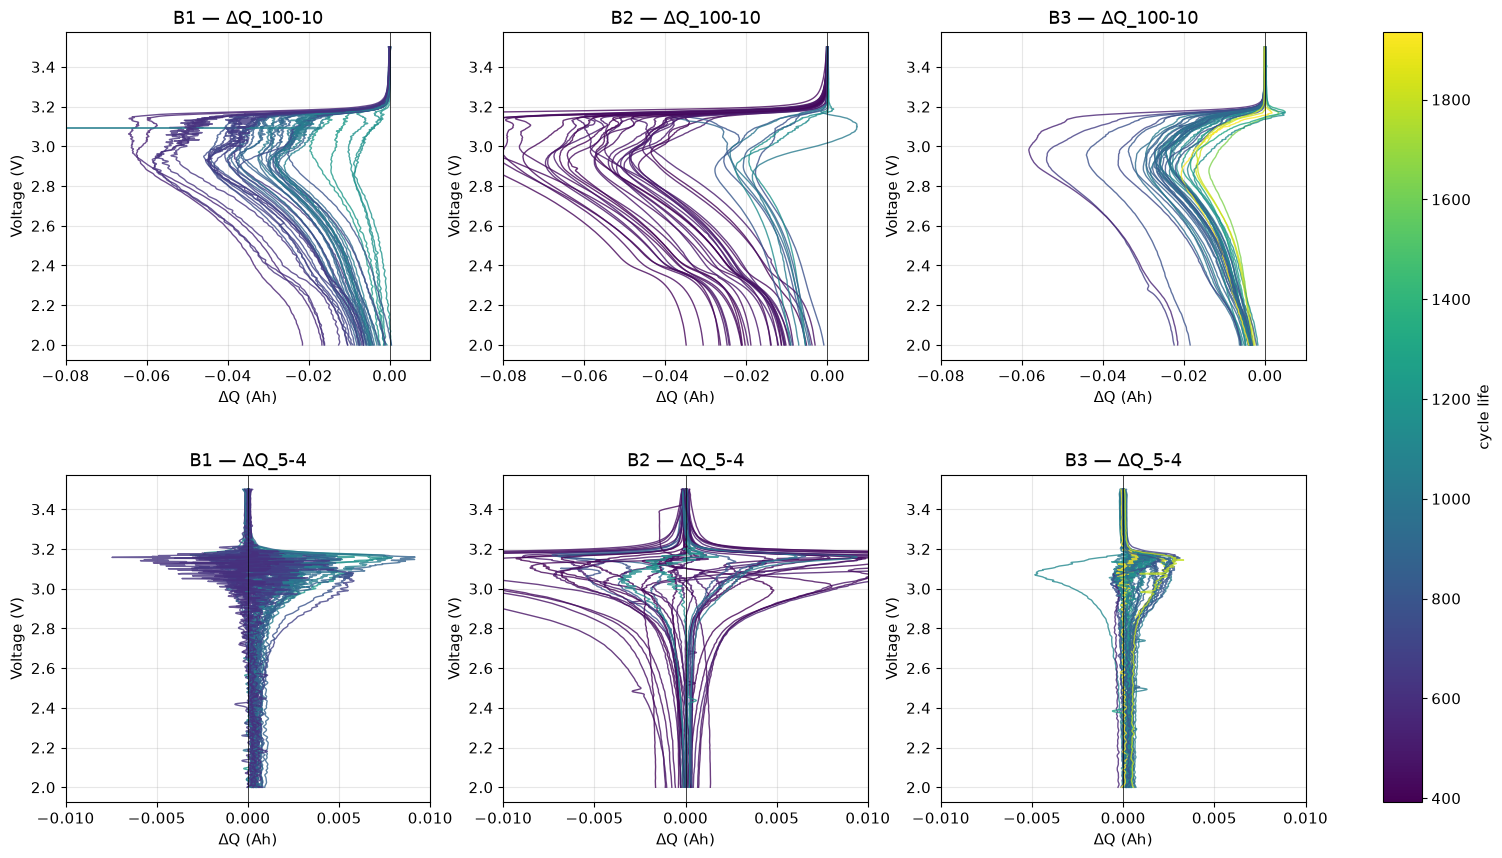

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.subplots_adjust(hspace=0.35)
for row, (n, m_, title) in enumerate([(100, 10, 'ΔQ_100-10'), (5, 4, 'ΔQ_5-4')]):
    for col, b in enumerate(BATCHES):
        ax = axes[row, col]
        for c, f_ in zip(cells, feat.itertuples()):
            if f_.batch != b:
                continue
            dq = c['Qdlin'][n] - c['Qdlin'][m_]
            ax.plot(dq, V, color=cm.viridis(norm(f_.cycle_life)), lw=1, alpha=0.8)
        ax.axvline(0, color='k', lw=0.5)
        ax.set(title=f'{b} — {title}', ylabel='Voltage (V)', xlabel='ΔQ (Ah)')
for ax in axes[0]:
    ax.set_xlim(-0.08, 0.01)
for ax in axes[1]:
    ax.set_xlim(-0.01, 0.01)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axes, label='cycle life')
plt.show()

**Long vs Short 평균 곡선** — 두 그룹의 평균 ± 1 표준편차 띠가 **겹치지 않으면** 구분이 잘 되는 것 (B1+B2 합쳐서)

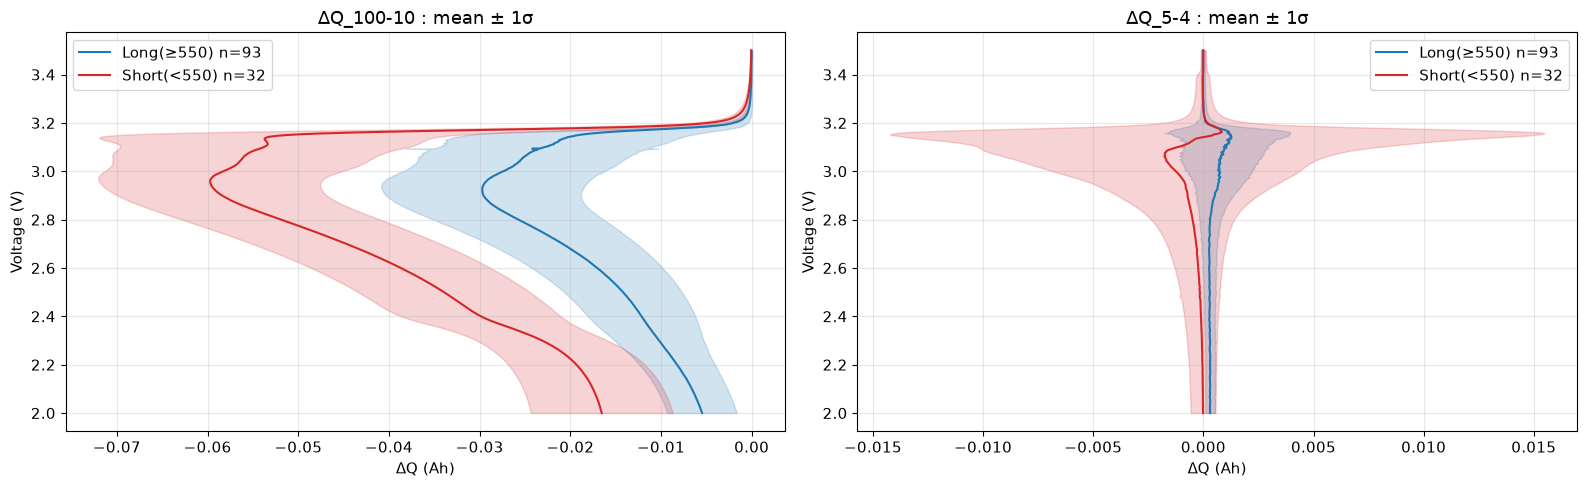

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (n, m_, title) in zip(axes, [(100, 10, 'ΔQ_100-10'), (5, 4, 'ΔQ_5-4')]):
    for lab, name in [(1, 'Long(≥550)'), (0, 'Short(<550)')]:
        dqs = np.vstack([c['Qdlin'][n] - c['Qdlin'][m_]
                         for c, l in zip(cells, feat['label']) if l == lab])
        mu, sd = np.nanmean(dqs, 0), np.nanstd(dqs, 0)
        ax.plot(mu, V, color=LABEL_COLOR[lab], label=f'{name} n={len(dqs)}')
        ax.fill_betweenx(V, mu - sd, mu + sd, color=LABEL_COLOR[lab], alpha=0.2)
    ax.set(title=f'{title} : mean ± 1σ', xlabel='ΔQ (Ah)', ylabel='Voltage (V)')
    ax.legend()
plt.tight_layout(); plt.show()

**ΔQ 를 숫자 1개로 요약한 피처 vs 수명**
- 논문 주장 : "ΔQ 곡선의 분산(log) 이 클수록 수명이 짧다 (거의 직선 관계)" → 배치별로 맞는지 확인
- 표의 `spearman_B1/B2` : −1 에 가까울수록 "피처가 클수록 수명이 짧다" 가 강함. **두 배치 부호가 같아야** 믿을 수 있는 피처
- 표의 `AUC_B2` : B2 안에서 Long/Short 분리력 (0.5 무작위 ~ 1.0 완벽)

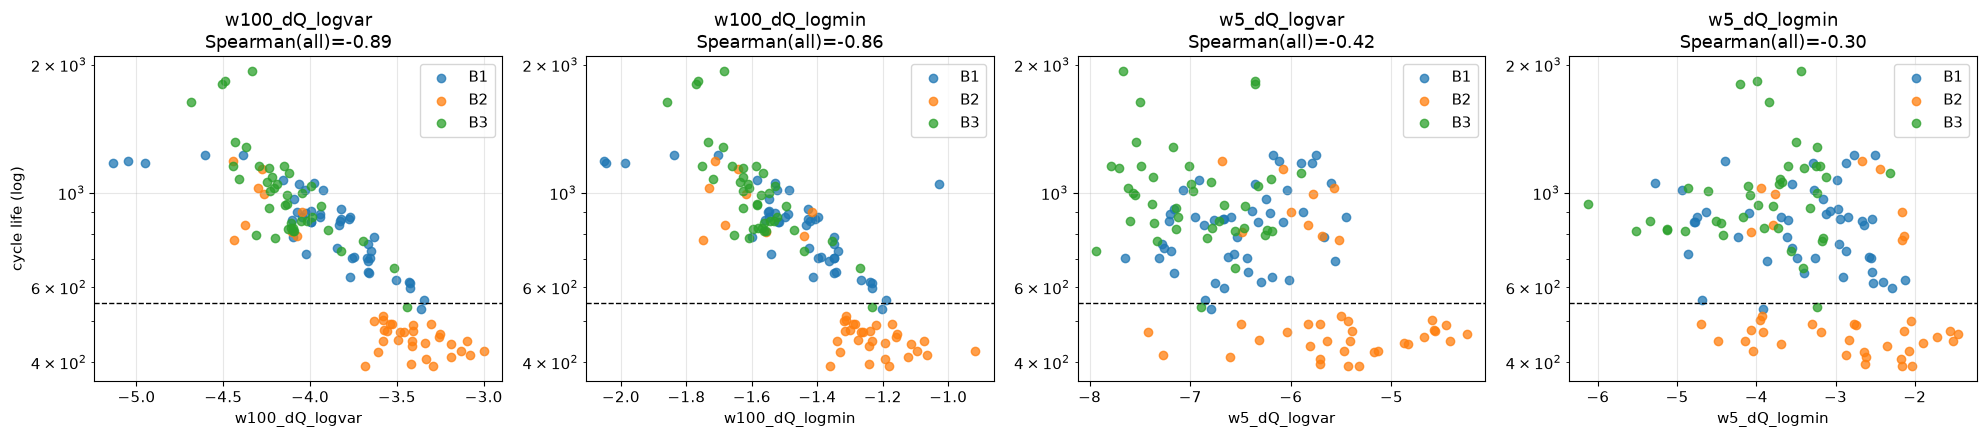

,spearman_B1,spearman_B2,spearman_B3,AUC_B2,AUC_all
feature,,,,,
w100_dQ_logvar,-0.853,-0.716,-0.765,1.000,0.970
w100_dQ_logmin,-0.771,-0.700,-0.758,1.000,0.955
w5_dQ_logvar,0.317,-0.218,-0.222,0.752,0.849
w5_dQ_logmin,-0.204,-0.233,0.215,0.552,0.699
w100_dQ_mean,0.826,0.716,0.717,1.000,0.957
w100_dQ_skew,-0.575,-0.147,-0.172,0.644,0.777
w100_dQ_kurt,0.313,0.485,0.148,0.893,0.600
w5_dQ_mean,0.407,0.207,-0.058,0.511,0.569


In [14]:
dq_cols = ['w100_dQ_logvar', 'w100_dQ_logmin', 'w5_dQ_logvar', 'w5_dQ_logmin']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, dq_cols):
    for b in BATCHES:
        sub = feat[feat.batch == b]
        ax.scatter(sub[col], sub['cycle_life'], color=BATCH_COLOR[b], alpha=0.75, label=b)
    ax.axhline(THRESHOLD, color='k', ls='--', lw=1)
    rho_all = stats.spearmanr(feat[col], feat['cycle_life'], nan_policy='omit').correlation
    ax.set(title=f'{col}\nSpearman(all)={rho_all:.2f}', xlabel=col, yscale='log')
    ax.legend()
axes[0].set_ylabel('cycle life (log)')
plt.tight_layout(); plt.show()

tbl = []
for col in dq_cols + ['w100_dQ_mean', 'w100_dQ_skew', 'w100_dQ_kurt', 'w5_dQ_mean']:
    r = {'feature': col}
    for b in BATCHES:
        sub = feat[feat.batch == b]
        r[f'spearman_{b}'] = stats.spearmanr(sub[col], sub['cycle_life'], nan_policy='omit').correlation
    r['AUC_B2']  = auc(feat.loc[feat.batch == 'B2', col].values, feat.loc[feat.batch == 'B2', 'label'].values)
    r['AUC_all'] = auc(feat[col].values, feat['label'].values)
    tbl.append(r)
q3_tbl = pd.DataFrame(tbl).set_index('feature').round(3)
display(q3_tbl)

**"몇 사이클까지 보면 충분한가?" — 관측 기간 바꿔보기**
- ΔQ_n − ΔQ_기준 의 log 분산을 n = 5, 10, 20, … 100 으로 바꿔 가며 수명과의 상관 / Long·Short 분리력 계산
- 선이 높아지다가 평평해지는 지점 = **입력으로 써야 할 최소 사이클 수**

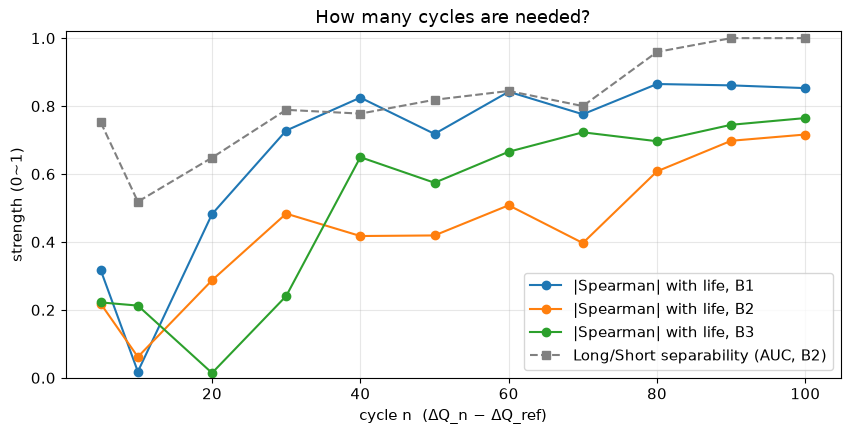

,n,ref,B1,B2,B3,AUC_B2
0,5,4,0.317,0.218,0.222,0.752
1,10,2,0.018,0.062,0.213,0.519
2,20,10,0.482,0.287,0.014,0.648
3,30,10,0.728,0.483,0.241,0.789
4,40,10,0.825,0.417,0.650,0.778
5,50,10,0.718,0.419,0.574,0.819
6,60,10,0.842,0.508,0.666,0.844
7,70,10,0.776,0.397,0.723,0.800
8,80,10,0.865,0.608,0.697,0.959
9,90,10,0.861,0.698,0.745,1.000


In [15]:
ns = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
sweep = []
for n in ns:
    ref = 4 if n == 5 else 10 if n > 10 else 2
    lv = np.array([np.log10(np.nanvar(c['Qdlin'][n] - c['Qdlin'][ref])) for c in cells])
    r = {'n': n, 'ref': ref}
    for b in BATCHES:
        mask = (feat['batch'] == b).values
        r[b] = abs(stats.spearmanr(lv[mask], feat.loc[mask, 'log_life']).correlation)
    r['AUC_B2'] = auc(lv[feat['batch'].values == 'B2'], feat.loc[feat.batch == 'B2', 'label'].values)
    sweep.append(r)
sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(10, 4.5))
for b in BATCHES:
    ax.plot(sweep['n'], sweep[b], 'o-', color=BATCH_COLOR[b], label=f'|Spearman| with life, {b}')
ax.plot(sweep['n'], sweep['AUC_B2'], 's--', color='gray', label='Long/Short separability (AUC, B2)')
ax.set(xlabel='cycle n  (ΔQ_n − ΔQ_ref)', ylabel='strength (0~1)', title='How many cycles are needed?', ylim=(0, 1.02))
ax.legend(); plt.show()
display(sweep.round(3))

### 📌 Q3 결과 해석

**관찰**
- ΔQ_100-10 에서는 Long/Short 의 ±1σ 띠가 거의 겹치지 않음 (Short 는 2.8~3.1V 에서 더 깊게 파임). ΔQ_5-4 는 완전히 겹침
- `w100_dQ_logvar` 와 수명의 Spearman : **B1 −0.85, B2 −0.72, B3 −0.76** → 세 배치 모두 강한 같은 방향
- `w5_dQ_logvar` 는 B1 +0.32, B2 −0.22, B3 −0.22 / `w5_dQ_logmin` 은 B3 에서 부호 반전 → 5사이클 신호는 불안정
- 관찰 기간 그래프 : 5사이클 |상관| 0.2~0.3 → 100사이클에서 최고. B2 분리력 0.75 → 1.0 (n ≥ 90)

**해석**
- 전체 용량은 같아도 곡선 모양 변화가 클수록 수명이 짧음 — 세 배치 공통이며 원논문 결과와 일치

**모델링 시사점**
- **핵심 피처 = ΔQ_100-10 분산**, **입력 = 초기 100사이클**
- ΔQ 분산과 log 수명이 직선 관계 → 선형 모델 적합

---
## Q4. 충전 조건(C-rate)과 수명의 관계는?

**용어**
- **C-rate** : 충전 속도. 1C = 1시간에 완충, 4C = 15분에 완충
- 충전 방식 `5.4C(50%)-3C` = 50% 까지는 5.4C 로, 그 다음 80% 까지는 3C 로 충전
- `Cavg` = 0→80% 평균 충전 속도 (2단계 충전을 숫자 하나로 요약). 클수록 공격적인 충전

**확인할 것** : 빠른 충전 = 짧은 수명인가? 그리고 이 관계가 **B1 과 B2 에서 똑같이** 성립하는가?

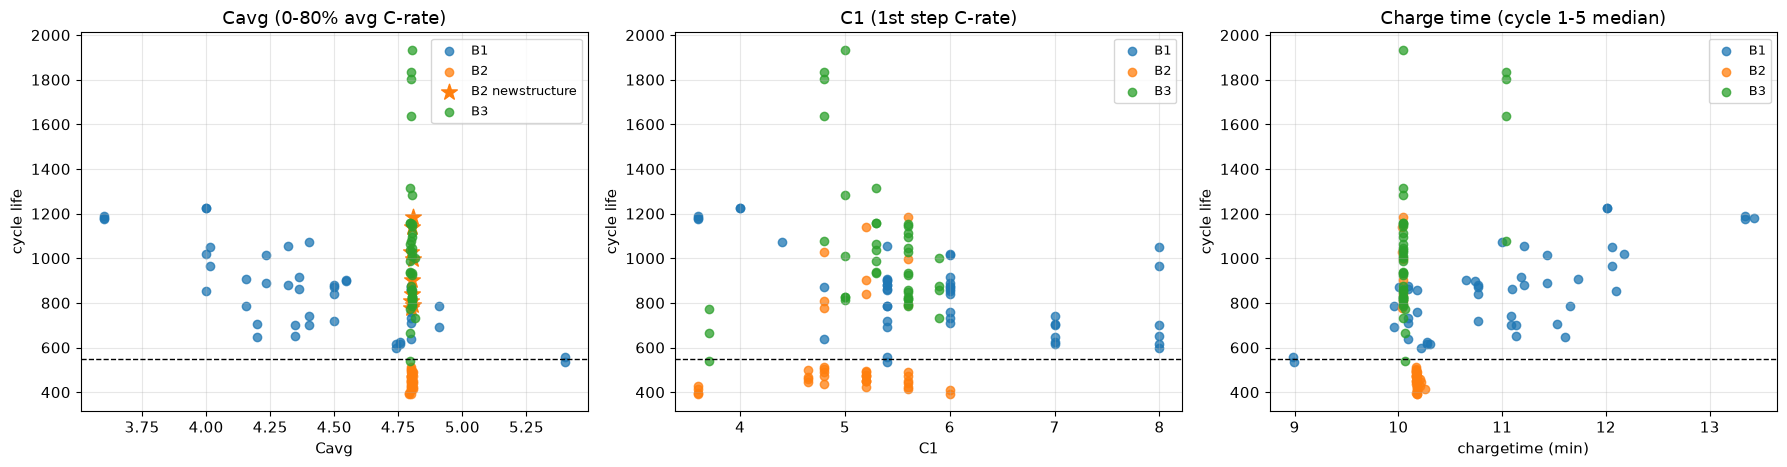

n  life_mean  life_std  Cavg  short_ratio
batch policy                                                                
B1    3.6C(80%)-3.6C               3     1182.0       7.0   3.6          0.0
      4C(80%)-4C                   2     1226.5       0.7   4.0          0.0
      6C(40%)-3C                   2      935.5     115.3   4.0          0.0
      8C(15%)-3.6C                 2     1008.5      60.1   4.0          0.0
      5.4C(50%)-3C                 2      847.0      83.4   4.2          0.0
      6C(30%)-3.6C                 2      952.5      87.0   4.2          0.0
      7C(40%)-3C                   2      676.0      39.6   4.2          0.0
      5.4C(40%)-3.6C               2      966.5     123.7   4.3          0.0
      8C(25%)-3.6C                 2      676.5      36.1   4.3          0.0
      4.4C(80%)-4.4C               1     1074.0       NaN   4.4          0.0
      6C(50%)-3C                   2      888.5      40.3   4.4          0.0
      7C(30%)-3.6C                 2      722.5      27.6   4.4          0.0
      5.4C(50%)-3.6C               2      899.5       3.5   4.5          0.0
      5.4C(60%)-3C                 2      799.5     113.8   4.5          0.0
      6C(40%)-3.6C                 2      856.0      19.8   4.5          0.0
      8C(35%)-3.6C                 2      607.5      12.0   4.7          0.0
      4.8C(80%)-4.8C               2      753.0     165.5   4.8          0.0
      5.4C(60%)-3.6C               2      859.5       3.5   4.8          0.0
      6C(50%)-3.6C                 2      792.5     118.1   4.8          0.0
      6C(60%)-3C                   2      744.0      18.4   4.8          0.0
      7C(40%)-3.6C                 2      621.0       5.7   4.8          0.0
      5.4C(70%)-3C                 2      739.5      68.6   4.9          0.0
      5.4C(80%)-5.4C               2      546.5      17.7   5.4          0.5
B2    3.6C(30%)-6C                 2      421.0       7.1   4.8          1.0
      3.6C(9%)-5C                  2      394.5       2.1   4.8          1.0
      4.65C(44%)-5C                2      482.5      23.3   4.8          1.0
      4.65C(69%)-6C                2      452.0      11.3   4.8          1.0
      4.8C(80%)-4.8C               5      483.6      30.3   4.8          1.0
      4.8C(80%)-4.8C-newstructure  3      871.7     137.2   4.8          0.0
      5.2C(50%)-4.25C              5      454.0      20.9   4.8          1.0
      5.2C(58%)-4C                 4      477.8      18.5   4.8          1.0
      5.2C(58%)-4C-newstructure    3      961.7     157.6   4.8          0.0
      5.6C(26%)-4.5C               6      448.5      29.1   4.8          1.0
      5.6C(26%)-4.5C-newstructure  3      991.3     197.6   4.8          0.0
      6C(60%)-3C                   2      400.0      11.3   4.8          1.0
B3    3.7C(31%)-5.9C-newstructure  3      660.0     115.7   4.8          0.3
      4.8C(80%)-4.8C-newstructure  4     1588.2     350.9   4.8          0.0
      5.3C(54%)-4C-newstructure    8     1074.4     129.7   4.8          0.0
      5.6C(19%)-4.6C-newstructure  7      963.4     148.7   4.8          0.0
      5.6C(36%)-4.3C-newstructure  8      930.9     135.0   4.8          0.0
      5.9C(15%)-4.6C-newstructure  2      867.0      12.7   4.8          0.0
      5.9C(60%)-3.1C-newstructure  2      866.5     191.6   4.8          0.0
      5C(67%)-4C-newstructure      6     1115.7     440.4   4.8          0.0

B1·B2 공통 충전 방식 : ['4.8C(80%)-4.8C', '6C(60%)-3C']
B1·B3 공통 충전 방식 : ['4.8C(80%)-4.8C']
B2·B3 공통 충전 방식 : ['4.8C(80%)-4.8C']
  4.8C(80%)-4.8C     평균 수명 {'B1': 753.0, 'B2': 629.0, 'B3': 1588.0}
  6C(60%)-3C         평균 수명 {'B1': 744.0, 'B2': 400.0}
        min   max
batch            
B1     3.60  5.40
B2     4.79  4.81
B3     4.79  4.81
B1 (B2 는 newstructure 제외) Spearman(Cavg, 수명) = -0.634  p=2.2e-06
B2 (B2 는 newstructure 제외) Spearman(Cavg, 수명) = 0.207  p=2.7e-01
B3 (B2 는 newstructure 제외) Spearman(Cavg, 수명) = -0.157  p=3.3e-01


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for b in BATCHES:
    sub = feat[feat.batch == b]
    ns_ = sub['newstruct'] & (b == 'B2')        # B3 는 전 셀이 newstructure 라 별도 표시 안 함
    axes[0].scatter(sub.loc[~ns_, 'Cavg'], sub.loc[~ns_, 'cycle_life'], color=BATCH_COLOR[b], label=b, alpha=0.75)
    if ns_.any():
        axes[0].scatter(sub.loc[ns_, 'Cavg'], sub.loc[ns_, 'cycle_life'], color=BATCH_COLOR[b],
                        marker='*', s=140, label=f'{b} newstructure')
    axes[1].scatter(sub['C1'], sub['cycle_life'], color=BATCH_COLOR[b], alpha=0.75, label=b)
    axes[2].scatter(sub['w5_chargetime'], sub['cycle_life'], color=BATCH_COLOR[b], alpha=0.75, label=b)
for ax, (t, xl) in zip(axes, [('Cavg (0-80% avg C-rate)', 'Cavg'), ('C1 (1st step C-rate)', 'C1'),
                              ('Charge time (cycle 1-5 median)', 'chargetime (min)')]):
    ax.axhline(THRESHOLD, color='k', ls='--', lw=1)
    ax.set(title=t, xlabel=xl, ylabel='cycle life'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

pol = (feat.groupby(['batch', 'policy'])
           .agg(n=('cycle_life', 'size'), life_mean=('cycle_life', 'mean'), life_std=('cycle_life', 'std'),
                Cavg=('Cavg', 'first'), short_ratio=('label', lambda x: 1 - x.mean()))
           .round(1).sort_values(['batch', 'Cavg']))
display(pol)

pol_sets = {b: set(feat.loc[feat.batch == b, 'policy_base']) for b in BATCHES}
shared = pol_sets['B1'] & pol_sets['B2']
print(f'B1·B2 공통 충전 방식 : {sorted(shared)}')
print(f'B1·B3 공통 충전 방식 : {sorted(pol_sets["B1"] & pol_sets["B3"])}')
print(f'B2·B3 공통 충전 방식 : {sorted(pol_sets["B2"] & pol_sets["B3"])}')
for p in sorted(set().union(*[pol_sets[a] & pol_sets[b] for a, b in [('B1', 'B2'), ('B1', 'B3'), ('B2', 'B3')]])):
    print(f'  {p:18s} 평균 수명', feat[feat.policy_base == p].groupby('batch')['cycle_life'].mean().round(0).to_dict())

print(feat.groupby('batch')['Cavg'].agg(['min', 'max']).round(2))
for b in BATCHES:
    sub = feat[(feat.batch == b) & ~(feat.newstruct & (b == 'B2'))]
    r = stats.spearmanr(sub['Cavg'], sub['cycle_life'])
    print(f'{b} (B2 는 newstructure 제외) Spearman(Cavg, 수명) = {r.correlation:.3f}  p={r.pvalue:.1e}')

**충전 속도 ↔ 초기 열화 속도** (가이드 Q4 세 번째 항목)

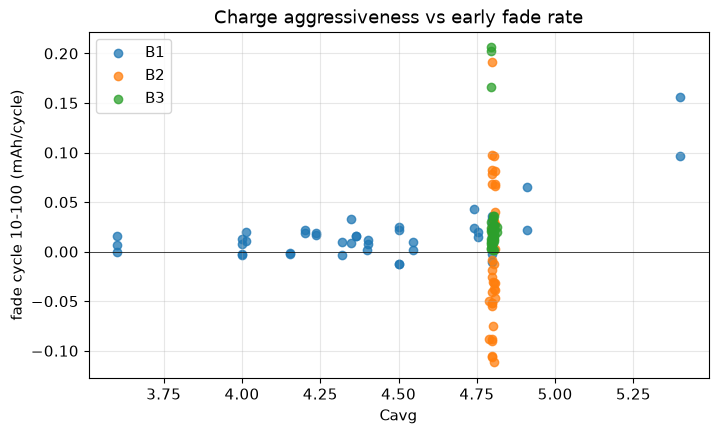

B1 Spearman(Cavg, 초기 열화 속도) = 0.5
B2 Spearman(Cavg, 초기 열화 속도) = 0.378
B3 Spearman(Cavg, 초기 열화 속도) = 0.1


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for b in BATCHES:
    sub = feat[feat.batch == b]
    ax.scatter(sub['Cavg'], -sub['early_rate'] * 1e3, color=BATCH_COLOR[b], alpha=0.75, label=b)
ax.axhline(0, color='k', lw=0.5)
ax.set(title='Charge aggressiveness vs early fade rate', xlabel='Cavg', ylabel='fade cycle 10-100 (mAh/cycle)')
ax.legend(); plt.show()
for b in BATCHES:
    sub = feat[feat.batch == b]
    print(b, 'Spearman(Cavg, 초기 열화 속도) =', round(stats.spearmanr(sub['Cavg'], -sub['early_rate']).correlation, 3))

**충전 단계별 전류 ↔ 열화 속도 / 수명** — 평균 충전 속도(Cavg)가 같은 B2·B3 에서도 단계 배분(C1, Q1, C2)은 셀마다 다름
- `C1` : 1단계 전류, `Q1` : 2단계로 넘어가는 SOC(%), `C2` : 2단계 전류
- 각 칸 : (초기 열화 속도와의 상관 / 수명과의 상관). B2 는 newstructure 를 뺀 일반 셀 기준도 함께 표시

In [18]:
step_rows = []
groups = [('B1', feat.batch == 'B1'), ('B2', feat.batch == 'B2'),
          ('B2 일반 셀', (feat.batch == 'B2') & ~feat.newstruct), ('B3', feat.batch == 'B3')]
for name, m in groups:
    sub = feat[m]
    r = {'group': name}
    for c in ['C1', 'Q1', 'C2']:
        fade = stats.spearmanr(sub[c], -sub['early_rate'])
        life = stats.spearmanr(sub[c], sub['log_life'])
        r[c] = f'{fade.correlation:+.2f} / {life.correlation:+.2f} (p={life.pvalue:.3f})'
    step_rows.append(r)
display(pd.DataFrame(step_rows).set_index('group'))

,C1,Q1,C2
group,,,
B1,+0.42 / -0.48 (p=0.001),-0.13 / +0.19 (p=0.218),+0.08 / +0.05 (p=0.754)
B2,+0.04 / +0.06 (p=0.739),-0.01 / +0.29 (p=0.076),+0.15 / -0.12 (p=0.471)
B2 일반 셀,-0.02 / -0.06 (p=0.747),-0.01 / +0.40 (p=0.030),+0.29 / -0.04 (p=0.822)
B3,+0.03 / -0.16 (p=0.314),-0.35 / +0.41 (p=0.009),+0.25 / -0.11 (p=0.488)


### 📌 Q4 결과 해석

**관찰**
- B1 : Cavg 가 클수록 수명이 짧음 (Spearman −0.63). 충전이 빠를수록 초기 열화 속도도 빨라짐 (+0.50)
- B2·B3 : 모든 셀의 Cavg 가 4.79~4.81 로 사실상 같음 (0→80% 충전 시간을 동일하게 설계). 그런데도 수명은 392~1935
- Cavg ↔ 수명 : B2 +0.21, B3 −0.16 으로 모두 유의하지 않음
- 공통 방식 4.8C(80%)-4.8C 의 평균 수명 : B1 753, B2 629, B3 1588
- **충전 단계별** : B1 은 1단계 전류(C1)가 클수록 초기 열화가 빠르고(+0.42) 수명이 짧음(−0.48). B2·B3 에서는 C1 영향이 사라지고,
  2단계 전환 시점(Q1)이 늦을수록 수명이 김 (B2 일반 셀 +0.40 p=0.03, B3 +0.41 p=0.009). 2단계 전류(C2)는 세 배치 모두 약함

**해석**
- B1 의 관계는 "고속 충전 → 리튬 석출·발열 → 열화 가속" 도메인 지식과 일치. 그러나 수명은 충전 조건보다 배치·셀 구조의 영향을 크게 받음

**모델링 시사점**
- 평균 충전 속도·충전 시간·1단계 전류는 배치마다 관계가 달라 **제외**, 셀의 실제 반응(ΔQ) 사용
- 전환 시점(Q1)은 세 배치 방향이 같아(+0.19 / +0.29 / +0.41) **보조 후보로 B1 CV 에서 검토** (B1 에서 약해 채택 가능성은 낮음)

---
## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

4가지를 본다.
1. **피처 ↔ 수명 상관 (배치별)** : `rho_B1`, `rho_B2`. 두 부호가 같아야(`sign_agree`) 믿을 수 있음
2. **피처 ↔ 피처 상관 (히트맵)** : 두 피처가 거의 같은 정보면 하나만 남김 (다중공선성)
3. **VIF** : 다른 피처들로 이 피처를 얼마나 설명할 수 있는지. 10 이상이면 중복이 심함
4. **KS_stat (배치 간 값 분포 차이)** : 0 = B1·B2 값 범위가 같음, 1 = 완전히 다름

In [19]:
CAND = ['w5_dQ_logvar', 'w5_dQ_logmin', 'w5_dQ_mean',
        'w100_dQ_logvar', 'w100_dQ_logmin', 'w100_dQ_mean', 'w100_dQ_skew', 'w100_dQ_kurt',
        'QD2', 'w5_QDmax_m_QD2', 'w100_QDmax_m_QD2', 'w100_fade_slope',
        'w5_chargetime', 'w5_Tavg', 'w5_Tmax', 'w100_Tavg',
        'IR2', 'w5_IR_min', 'w100_IR_delta', 'Cavg', 'C1']

rows = []
for col in CAND:
    r = {'feature': col}
    for b in BATCHES:
        sub = feat[feat.batch == b]
        r[f'rho_{b}'] = stats.spearmanr(sub[col], sub['log_life'], nan_policy='omit').correlation
    r['sign_agree'] = np.sign(r['rho_B1']) == np.sign(r['rho_B2'])
    r['sign_agree_all'] = r['sign_agree'] and np.sign(r['rho_B1']) == np.sign(r['rho_B3'])
    r['AUC_B2']     = auc(feat.loc[feat.batch == 'B2', col].values, feat.loc[feat.batch == 'B2', 'label'].values)
    ks_ = stats.ks_2samp(feat.loc[feat.batch == 'B1', col].dropna(), feat.loc[feat.batch == 'B2', col].dropna())
    r['KS_stat'], r['KS_p'] = ks_.statistic, ks_.pvalue
    rows.append(r)
q5 = pd.DataFrame(rows).set_index('feature')
q5['min_abs_rho'] = q5[['rho_B1', 'rho_B2', 'rho_B3']].abs().min(axis=1).where(q5['sign_agree_all'], 0)
q5 = q5.sort_values('min_abs_rho', ascending=False)
display(q5.round(3).style.background_gradient(subset=['rho_B1', 'rho_B2', 'rho_B3'], cmap='RdBu', vmin=-1, vmax=1)
          .background_gradient(subset=['KS_stat'], cmap='Oranges', vmin=0, vmax=1))

,rho_B1,rho_B2,rho_B3,sign_agree,sign_agree_all,AUC_B2,KS_stat,KS_p,min_abs_rho
feature,,,,,,,,,
w100_dQ_logvar,-0.853000,-0.716000,-0.765000,True,True,1.000000,0.613000,0.000000,0.716000
w100_dQ_mean,0.826000,0.716000,0.717000,True,True,1.000000,0.536000,0.000000,0.716000
w100_dQ_logmin,-0.771000,-0.700000,-0.758000,True,True,1.000000,0.570000,0.000000,0.700000
w100_dQ_kurt,0.313000,0.485000,0.148000,True,True,0.893000,0.256000,0.101000,0.148000
w100_dQ_skew,-0.575000,-0.147000,-0.172000,True,True,0.644000,0.485000,0.000000,0.147000
QD2,0.072000,0.101000,0.208000,True,True,0.633000,0.737000,0.000000,0.072000
w5_Tmax,-0.269000,-0.199000,-0.072000,True,True,0.526000,0.290000,0.044000,0.072000
w5_dQ_logvar,0.317000,-0.218000,-0.222000,False,False,0.752000,0.613000,0.000000,0.000000
Cavg,-0.634000,0.321000,-0.157000,False,False,0.683000,0.739000,0.000000,0.000000


**표 읽는 법**
- `min_abs_rho` : "두 배치 **모두** 에서 같은 방향으로 얼마나 강한가" (방향이 다르면 0). **위에 있을수록 좋은 피처 후보**
- `KS_stat` 이 크면 : B2 의 값이 B1 에서 본 적 없는 범위에 있다는 뜻
  → 트리 모델(RandomForest, XGBoost)은 학습 때 본 범위 밖은 끝값으로 고정해 버림. 선형 모델은 직선을 연장해서 예측 가능

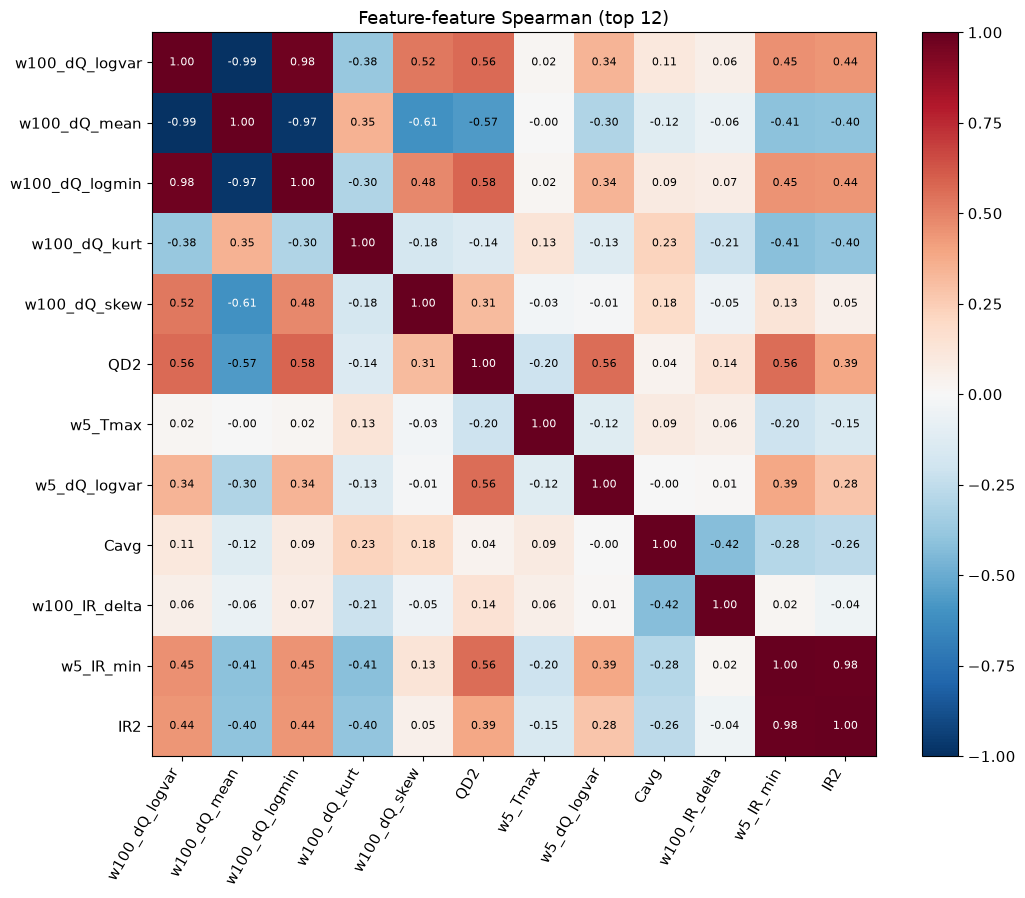

,VIF
IR2,320.3
w100_dQ_logvar,313.4
w5_IR_min,308.7
w100_dQ_logmin,279.2
w100_dQ_mean,20.9
w100_dQ_kurt,16.9
w100_dQ_skew,3.5
QD2,3.0
Cavg,1.9
w100_IR_delta,1.8


|상관| ≥ 0.85 피처 쌍 (둘 중 하나만 남길 후보):
  w100_dQ_logvar         ~ w100_dQ_mean           : -0.99
  w5_IR_min              ~ IR2                    : 0.98
  w100_dQ_logvar         ~ w100_dQ_logmin         : 0.98
  w100_dQ_mean           ~ w100_dQ_logmin         : -0.97


In [20]:
top = q5.index[:12].tolist()
cm_ = feat[top].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=60, ha='right')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top)
for i in range(len(top)):
    for j in range(len(top)):
        ax.text(j, i, f'{cm_.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(cm_.iloc[i, j]) > 0.6 else 'black')
plt.colorbar(im); ax.set_title('Feature-feature Spearman (top 12)'); ax.grid(False)
plt.tight_layout(); plt.show()

def vif(df):
    """각 피처를 나머지 피처들로 선형회귀 → VIF = 1 / (1 - R²)"""
    X = (df - df.mean()) / df.std()
    out = {}
    for col in X:
        y_, X_ = X[col].values, np.column_stack([np.ones(len(X)), X.drop(columns=col).values])
        beta, *_ = np.linalg.lstsq(X_, y_, rcond=None)
        r2 = 1 - ((y_ - X_ @ beta) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
        out[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out, name='VIF').sort_values(ascending=False)

display(vif(feat[top].dropna()).round(1).to_frame())

pairs = [(a, b_, cm_.loc[a, b_]) for i, a in enumerate(top) for b_ in top[i + 1:] if abs(cm_.loc[a, b_]) >= 0.85]
print('|상관| ≥ 0.85 피처 쌍 (둘 중 하나만 남길 후보):')
for a, b_, v in sorted(pairs, key=lambda t: -abs(t[2])):
    print(f'  {a:22s} ~ {b_:22s} : {v:.2f}')

**배치 × 라벨별 피처 값 분포** — B1-L(B1 Long), B1-S(B1 Short), B2-L, B2-S 상자가 어디에 있는지 비교

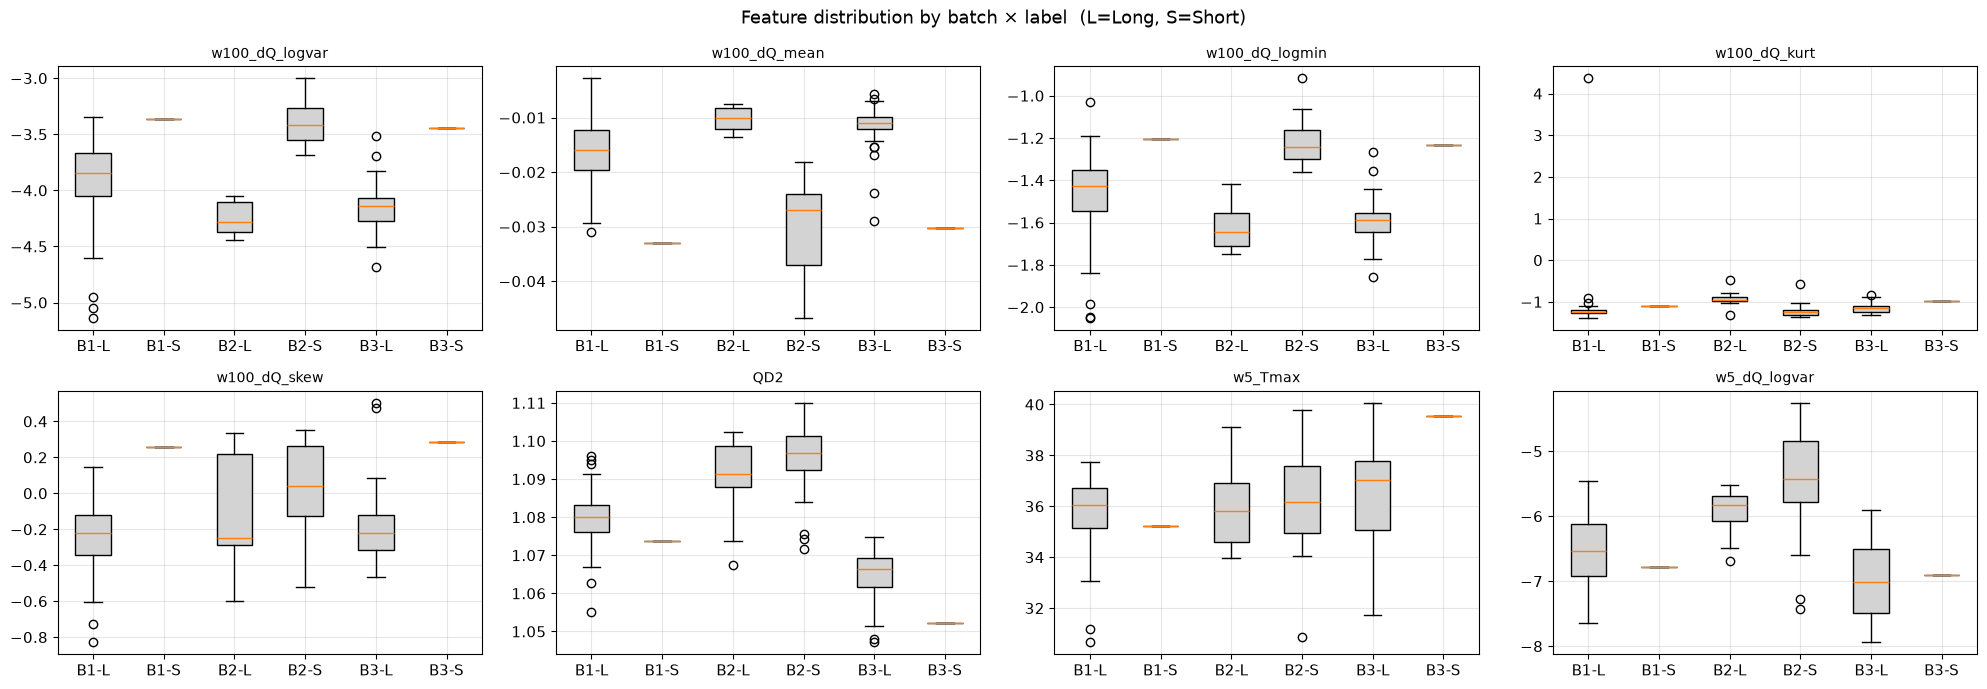

In [21]:
show = top[:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
for ax, col in zip(axes.ravel(), show):
    data = [feat.loc[(feat.batch == b) & (feat.label == l), col].dropna()
            for b in BATCHES for l in [1, 0]]
    ax.boxplot(data, tick_labels=['B1-L', 'B1-S', 'B2-L', 'B2-S', 'B3-L', 'B3-S'], patch_artist=True,
               boxprops=dict(facecolor='lightgray'))
    ax.set_title(col, fontsize=10)
plt.suptitle('Feature distribution by batch × label  (L=Long, S=Short)'); plt.tight_layout(); plt.show()

### 📌 Q5 결과 해석

**관찰**
- 세 배치에서 같은 방향으로 강한 피처는 ΔQ_100-10 계열 3개 (분산 −0.85/−0.72/−0.76, 평균, 최솟값) 뿐
- 후보 21개 중 11개는 B1·B2 에서 방향이 반대, B3 까지 보면 14개가 일관되지 않음 (예 : 충전 시간 +0.63 / −0.83 / +0.06)
- 다중공선성 : ΔQ 분산·평균·최솟값의 상관 0.97~0.99, VIF 200 이상
- 박스플롯 : ΔQ 분산은 배치마다 Long/Short 를 잘 나누지만, 배치 간 값 범위가 다름 (B1 대비 KS : B2 0.61, B3 0.53)

**해석**
- B1 만 보고 피처를 고르면 다른 배치에서 반대로 작동하는 "가짜 신호" 를 고르게 됨

**모델링 시사점**
- 선별 기준 = 배치 간 방향이 같은 피처 (후보 축소), 최종 조합은 B1 CV 로 결정
- 한계 : 테스트 배치 정보를 참고한 기준 → Day 2 에 B1 상관만으로 고른 세트와 성능 비교
- 중복 피처는 대표 1개 또는 ElasticNet 규제

---
## 6. 핵심 리스크 — "같은 ΔQ 신호인데 배치마다 수명이 다르다"

- 가장 강한 피처 `w100_dQ_logvar` 와 수명을 배치별로 한 그래프에 그림 (o = Long, x = Short)
- 파란 점선 = **B1 데이터만으로 그은 추세선** (학습 데이터만 보고 만들 수 있는 규칙)
- 파란 세로선 = B1 추세선이 550 이 되는 지점 = "B1 만 보고 정한 Long/Short 경계"
- 회색 세로선 = 두 배치를 합쳐서 찾은 최적 경계 (**테스트 정답을 본 것이므로 참고용**)

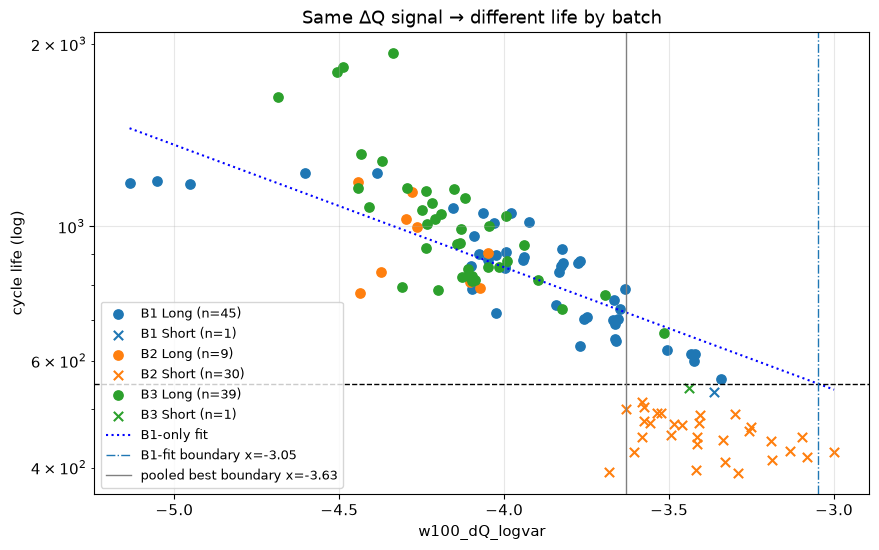

B1 : B1 추세선 수명 예측 MAPE = 9.8%  | 예측-실제 순위 상관 = 0.85  | 550 정확도 = 0.978 (전부 Long 예측 시 0.978)
B2 : B1 추세선 수명 예측 MAPE = 36.5%  | 예측-실제 순위 상관 = 0.72  | 550 정확도 = 0.256 (전부 Long 예측 시 0.231)
B3 : B1 추세선 수명 예측 MAPE = 13.1%  | 예측-실제 순위 상관 = 0.76  | 550 정확도 = 0.975 (전부 Long 예측 시 0.975)
B3 유일한 Short : B3c28 수명 541, ΔQ 분산 순위 1 / 40, B1 추세선 예측 660


,경계 위치,B1 정확도,B2 정확도,B3 정확도
B1 추세선 기준 (학습셋만 사용),-3.048,0.978,0.256,0.975
세 배치 합쳐 최적 (참고용),-3.631,0.891,0.974,0.975


참고 : B2 를 전부 Short 로 찍으면 정확도 0.769, 전부 Long 으로 찍으면 0.231


In [22]:
X_COL = 'w100_dQ_logvar'
b1, b2, b3 = (feat[feat.batch == b] for b in BATCHES)
coef = np.polyfit(b1[X_COL], b1['log_life'], 1)
thr_b1 = (np.log10(THRESHOLD) - coef[1]) / coef[0]          # B1 추세선이 550 이 되는 x

xs_sorted = np.sort(feat[X_COL].values)
accs = [((feat[X_COL] < t).astype(int) == feat['label']).mean() for t in xs_sorted]
thr_pool = xs_sorted[int(np.argmax(accs))]

fig, ax = plt.subplots(figsize=(10, 6))
for b, sub in [('B1', b1), ('B2', b2), ('B3', b3)]:
    for lab, mk in [(1, 'o'), (0, 'x')]:
        s_ = sub[sub.label == lab]
        ax.scatter(s_[X_COL], s_['cycle_life'], color=BATCH_COLOR[b], marker=mk, s=45,
                   label=f'{b} {"Long" if lab else "Short"} (n={len(s_)})')
xx = np.linspace(feat[X_COL].min(), feat[X_COL].max(), 50)
ax.plot(xx, 10 ** np.polyval(coef, xx), 'b:', label='B1-only fit')
ax.axhline(THRESHOLD, color='k', ls='--', lw=1)
ax.axvline(thr_b1, color='tab:blue', ls='-.', lw=1, label=f'B1-fit boundary x={thr_b1:.2f}')
ax.axvline(thr_pool, color='gray', lw=1, label=f'pooled best boundary x={thr_pool:.2f}')
ax.set(yscale='log', xlabel=X_COL, ylabel='cycle life (log)', title='Same ΔQ signal → different life by batch')
ax.legend(fontsize=9); plt.show()

def acc_at(df, t):
    return ((df[X_COL] < t).astype(int) == df['label']).mean()

chk = pd.DataFrame({
    '경계 위치' : [thr_b1, thr_pool],
    'B1 정확도' : [acc_at(b1, thr_b1), acc_at(b1, thr_pool)],
    'B2 정확도' : [acc_at(b2, thr_b1), acc_at(b2, thr_pool)],
    'B3 정확도' : [acc_at(b3, thr_b1), acc_at(b3, thr_pool)],
}, index=['B1 추세선 기준 (학습셋만 사용)', '세 배치 합쳐 최적 (참고용)']).round(3)
# 수명 예측 오차 : B1 추세선으로 각 배치의 수명을 예측했을 때 (배치 간 관계 이동 크기)
for b, sub in [('B1', b1), ('B2', b2), ('B3', b3)]:
    pred = 10 ** np.polyval(coef, sub[X_COL])
    print(f'{b} : B1 추세선 수명 예측 MAPE = {np.mean(np.abs(pred - sub.cycle_life) / sub.cycle_life) * 100:.1f}%  '
          f'| 예측-실제 순위 상관 = {stats.spearmanr(pred, sub.cycle_life).correlation:.2f}  '
          f'| 550 정확도 = {((pred >= THRESHOLD).astype(int) == sub.label).mean():.3f} (전부 Long 예측 시 {sub.label.mean():.3f})')
s3 = b3.sort_values(X_COL, ascending=False).reset_index(drop=True)
short3 = s3[s3.label == 0].iloc[0]
print(f'B3 유일한 Short : {short3.cell} 수명 {short3.cycle_life}, ΔQ 분산 순위 {s3.index[s3.label == 0][0] + 1} / {len(s3)}, '
      f'B1 추세선 예측 {10 ** np.polyval(coef, short3[X_COL]):.0f}')
display(chk)
print(f'참고 : B2 를 전부 Short 로 찍으면 정확도 {1 - b2.label.mean():.3f}, 전부 Long 으로 찍으면 {b2.label.mean():.3f}')

### 📌 6 결과 해석

**관찰**
- B3 셀(전부 newstructure)과 B2 newstructure 셀은 B1 추세선 위에 놓임. **B2 의 일반 셀만** 같은 ΔQ 값에서 수명이 짧음
- B1 추세선 수명 예측 MAPE : B1 9.8%, **B2 36.5%**, B3 13.1% / 예측-실제 순위 상관 : 0.85, 0.72, 0.76
- 550 판정 정확도는 B1·B3 모두 0.98 이지만 **"전부 Long" 예측과 같은 값** (Short 가 1개뿐) → 판정 성능 근거로 쓰지 않음
- B3 의 유일한 Short(541)는 B3 에서 ΔQ 분산 1위(40셀 중)인데 B1 추세선은 660 으로 예측 → 순서는 맞고 절대 수명 기준이 어긋남
- B3 의 ΔQ 분산은 B1 범위 밖까지 퍼져 있지만 B1 직선 연장이 수명을 13% 오차로 맞힘

**해석**
- ΔQ ↔ 수명 관계는 대체로 배치를 넘어 유지되며 B2 일반 셀만 예외 → 모델이 아니라 B2 일부 셀의 데이터 특성 문제
- 원인 가설 : B2 일반 셀의 제조 lot 차이, 실험 시기(약 9개월 후)·장비 조건 차이
- 학습 범위 밖 값(B3)도 직선 연장으로 예측됨 → 선형 모델 선택의 근거

**대응 (Day 2)**
- B2 에서 기준과 무관한 AUC 를 보조 보고, 오분류 셀이 B2 일반 셀에 몰리는지 확인
- 소량 라벨로 판정 기준만 재보정했을 때의 성능을 별도 시나리오로 제시

---
## 7. 전략 근거 요약 (보고서 표로 옮기기)

앞에서 나온 숫자만 모아 "EDA 결과 → 시사점" 표로 정리. 보고서에 그대로 옮겨 쓰면 됨.

In [23]:
best = q5.index[0]
flipped = q5.index[~q5['sign_agree']].tolist()
evidence = pd.DataFrame([
    ['Q1', 'B1 라벨 (Long / Short)', f"{b1.label.sum()} / {(1 - b1.label).sum()}",
     '학습셋에 Short 거의 없음 → 분류 경계 학습 불가'],
    ['Q1', 'B2 라벨 (Long / Short)', f"{b2.label.sum()} / {(1 - b2.label).sum()}",
     '테스트는 Short 다수 → 클래스 비율 역전, F1 필수'],
    ['Q1', '수명 분포 KS p (B1 vs B2)', f'{ks.pvalue:.1e}', '배치 간 수명 분포 다름'],
    ['Q1', '중도 종료 셀 (모두 Long)', f'{int(feat.censored.sum())}', '분류 라벨은 유효'],
    ['Q1', 'B2 newstructure vs 일반 수명 중앙값', f"{b2[b2.newstruct].cycle_life.median():.0f} vs {b2[~b2.newstruct].cycle_life.median():.0f}",
     'B2 Long 은 전부 newstructure → 셀 구조 효과'],
    ['Q2', 'knee / 수명 중앙값', f"{feat.knee_ratio.median():.2f}", '후반 급가속(비선형) → 초기 용량만으로 부족'],
    ['Q3', '최강 공통 피처', best, '두 배치 같은 방향 → 핵심 피처'],
    ['Q3', f'{best} 상관 B1 / B2', f"{q5.loc[best, 'rho_B1']:.2f} / {q5.loc[best, 'rho_B2']:.2f}", ''],
    ['Q3', 'w5_dQ_logvar 상관 B1 / B2',
     f"{q5.loc['w5_dQ_logvar', 'rho_B1']:.2f} / {q5.loc['w5_dQ_logvar', 'rho_B2']:.2f}", '5사이클은 신호 약함 → 100사이클 사용'],
    ['Q4', 'B1·B2 공통 충전 방식 수', f'{len(shared)}', '충전 방식 피처는 배치 간 통하지 않음'],
    ['Q5', '배치 간 방향 뒤집힘 피처', ', '.join(flipped[:6]) + (' ...' if len(flipped) > 6 else ''), '제외'],
    ['Q5', '|상관|≥0.85 중복 쌍 수', f'{len(pairs)}', '대표 1개만 사용 / 규제 모델'],
    ['Q1', 'B3 라벨 (Long / Short)', f"{b3.label.sum()} / {(1 - b3.label).sum()}", 'B3 도 Short 1개 → F1·Accuracy·AUC 대신 MAPE·순위 상관 중심 해석'],
    ['Q3', f'{best} 상관 B3', f"{q5.loc[best, 'rho_B3']:.2f}", '세 배치 공통 신호'],
    ['6', 'B1 경계로 B2 분류 정확도', f"{chk.iloc[0]['B2 정확도']:.2f}", 'B2 일반 셀만 관계 이동 → B2 Gap 예상 (B3 정확도는 전부 Long 과 같아 근거 아님)'],
], columns=['Q', '항목', '값', '시사점'])
display(evidence)
os.makedirs('../data/processed', exist_ok=True)
feat.to_csv('../data/processed/features_day1.csv', index=False)
print('features_day1.csv 저장 (Day 2 모델링 입력으로 재사용)')

,Q,항목,값,시사점
0,Q1,B1 라벨 (Long / Short),45 / 1,학습셋에 Short 거의 없음 → 분류 경계 학습 불가
1,Q1,B2 라벨 (Long / Short),9 / 30,"테스트는 Short 다수 → 클래스 비율 역전, F1 필수"
2,Q1,수명 분포 KS p (B1 vs B2),6.6e-13,배치 간 수명 분포 다름
3,Q1,중도 종료 셀 (모두 Long),10,분류 라벨은 유효
4,Q1,B2 newstructure vs 일반 수명 중앙값,904 vs 451,B2 Long 은 전부 newstructure → 셀 구조 효과
5,Q2,knee / 수명 중앙값,0.78,후반 급가속(비선형) → 초기 용량만으로 부족
6,Q3,최강 공통 피처,w100_dQ_logvar,두 배치 같은 방향 → 핵심 피처
7,Q3,w100_dQ_logvar 상관 B1 / B2,-0.85 / -0.72,
8,Q3,w5_dQ_logvar 상관 B1 / B2,0.32 / -0.22,5사이클은 신호 약함 → 100사이클 사용
9,Q4,B1·B2 공통 충전 방식 수,2,충전 방식 피처는 배치 간 통하지 않음


features_day1.csv 저장 (Day 2 모델링 입력으로 재사용)


---
## 8. 모델 설계 전략 (EDA 근거 기반)

**한 줄 요약** : ΔQ_100-10 분산 중심의 최소 피처 + **log 수명을 ElasticNet 으로 예측 → 550 기준으로 Long/Short 판정**

### 8-1. Feature Engineering

| 구분 | 피처 | 근거 |
|---|---|---|
| **핵심** | `w100_dQ_logvar` | 세 배치 모두 강한 같은 방향 상관 (−0.85 / −0.72 / −0.76), B2 안에서 Long/Short 분리력 1.0 (Q3, Q5) |
| 보조 후보 | `w100_dQ_kurt` | 두 배치 같은 방향 (+0.31 / +0.49), 핵심 피처와 상관 −0.21 → 다른 정보 (Q5 히트맵) |
| 보조 후보 | `w100_dQ_skew` | 같은 방향이지만 B2 에서 약함 (−0.58 / −0.15) → B1 CV 에서 개선될 때만 추가 |
| 제외 | `w100_dQ_mean`, `w100_dQ_logmin` | 핵심 피처와 상관 0.94~0.98, VIF ≈ 190 → 같은 정보 중복 (Q5) |
| 제외 | `Cavg`, `C1`, `chargetime` | B1 ↔ B2 상관 방향 반대 (충전시간 +0.63 → −0.83), B2 는 모두 Cavg 4.8 (Q4) |
| 제외 | `IR`, `Tavg`, `fade_slope` | 배치 간 상관 방향 반대 (Q5) |
| 제외 | `w5_*` (5사이클) | 신호 약함 (|상관| ≤ 0.3), 방향 불안정 (Q3) |

선택 원칙 : **"B1 에서 강한 피처" 가 아니라 "세 배치 모두에서 같은 방향으로 작동하는 피처"** — 테스트가 다른 배치이기 때문 (한계 : 테스트 배치 정보 참고 → Day 2 에 B1 단독 선별 세트와 비교)

### 8-2. 문제 정의 (Classification 선택)
- 최종 타깃 : `label = (cycle_life >= 550)` (1 = Long, 0 = Short), 평가 F1 / Accuracy
- 입력 기간 : 초기 **100 사이클** — n=5 분리력 0.75 → n≥90 분리력 1.0 (Q3 관측 기간 그래프)
- 학습 방식 : **log10(수명) 회귀 → 예측값 ≥ 550 이면 Long**
  - B1 에 Short 가 1개뿐 (Q1) → 분류기를 직접 학습하면 경계를 배울 수 없음. "전부 Long" 만으로 학습 정확도 98% 착시
  - 회귀는 46개 셀의 수명 숫자 전체를 학습 정보로 사용
  - 피처와 log 수명이 직선 관계 (Q3) → 회귀가 안정적
  - 최종 출력은 Long/Short 이므로 "분류 하나만 선택" 조건 충족

### 8-3. 데이터 처리 & 검증 설계

| 처리 | 내용 | 근거 |
|---|---|---|
| 셀 제외 | 수명 없는 B2 셀 8개 | 0-2 |
| 중도 종료 셀 10개 | 회귀 학습에서 제외, 라벨 평가에는 사용 | 수명이 하한값 → 학습 시 기울기 왜곡 |
| 타깃 변환 | log10(cycle_life) | 분포 치우침 (B2 skew 1.64), 피처와 직선 관계 |
| 스케일링 | StandardScaler, **B1 으로만 fit** | B2 정보 누수 방지 |
| 분류 기준 | 550 고정, B2 결과로 조정하지 않음 | 테스트 정답 사용 방지 |

- Train (B1 CV) : **GroupKFold (그룹 = 충전 방식)** — 같은 방식 셀이 학습/검증에 나뉘는 누수 방지 (가이드 지적 사항)
- Valid (B1 Hold-out) : 충전 방식 단위로 약 20% 분리
- 주의 : B1 검증셋의 Short 는 0~1개 → Short 기준 F1 불안정 → **회귀 단계 MAPE 를 보조 지표로 함께 보고**

### 8-4. 후보 모델 & 선택 논리

| 모델 | 역할 | EDA 연결 |
|---|---|---|
| **ElasticNet 회귀 → 550 판정** | ⭐ 최종 추천 | 아래 이유 |
| 단일 피처 선형회귀 (logvar) | 기준선 (논문 variance model) | 피처 추가 효과 비교 기준 |
| Logistic Regression (balanced) | 비교 | 직접 분류의 실패 근거 (Q1) |
| RandomForest 회귀 → 550 판정 | 비교 | 트리 모델의 범위 밖 예측 한계 (KS 0.61) |
| 다수결 (전부 Long) | 최저 기준선 | 정확도 착시 (B1 98% → B2 23%) |

**ElasticNet 추천 이유**
1. 직선 관계 : log 분산 ↔ log 수명이 직선 (Q3) → 선형 모델로 충분
2. 범위 밖 예측 : B2 피처 값이 B1 범위를 벗어남 (KS 0.61) → 직선 연장이 가능한 선형 모델 유리, 트리는 끝값에 고정
3. 표본 적음 : 학습 셀 36~46개 → 규제 있는 단순 모델이 과적합에 안전
4. 중복 피처 : ΔQ 계열 VIF ≈ 190 → L2 로 계수 안정, L1 으로 불필요 피처 자동 제거
5. 해석 가능 : "ΔQ 분산 ↑ → 수명 ↓" 를 계수로 설명 → ESS 운영 해석에 유리

### 8-5. 예상 결과 & 리스크
- **예상 Gap** : B3 는 수명 오차가 B1 과 비슷한 수준(MAPE 13%) 유지, B2 테스트 성능 크게 하락 (B1 직선 MAPE 36.5%, 6번)
- **원인** : 같은 ΔQ 값에서도 B2 셀이 더 일찍 수명 종료 → 피처↔수명 관계가 배치마다 다름
  (실험 시기, 셀 구조 newstructure, 충전 설계 차이)
- **모델 문제가 아닌 이유** : 피처는 B2 안에서 완벽하게 분리 (1.0) → **경계 위치를 B1 만으로 정할 수 없는 것** 이 문제
- **개선 방향** : 새 배치의 소량 라벨로 기준 재조정, 셀 구조/실험 조건 정보 추가
  → ESS 운영 시사점 : "새 제조 lot 이 들어오면 예측 기준을 다시 맞춰야 한다"